# 📊 Full EDA — Enterprise E-Commerce Predictive Analytics

This notebook consolidates all six dashboard EDA analyses into a single file.
Each section corresponds to a Power BI dashboard page and is clearly separated.

**Sections:**
1. Sales Overview (Dashboard 1)
2. Product EDA (Dashboard 2)
3. Revenue & Marketplace Trends (Dashboard 3)
4. Marketing & PPC Analysis (Dashboard 4)
5. Refund Leakage & Quality Control (Dashboard 5)
6. Promotions & Returns Analysis (Dashboard 6)


## Section 0 — Setup & Data Loading

Load the fully joined **`Star_Schema`** table produced by the Gold Layer.
No further joining or merging is needed here — the Gold Layer notebook
already performs all dimension-fact joins and exports the result.

> **Path note:** Set the path to wherever your `Star Schema.xlsx` lives.
> - **Local (cloned repo):** `../../Medallion Architecture/Gold Layer/Star Schema.xlsx`
> - **Google Colab:** upload the file and use `/content/Star Schema.xlsx`
> - **GitHub raw (read-only):** the individual CSVs are available on the repo (note: does not include the pre-joined `Star_Schema` sheet).


In [1]:
# ── Libraries ────────────────────────────────────────────────────────────
import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

try:
    import plotly.express as px
    import plotly.graph_objects as go
    PLOTLY_AVAILABLE = True
except ImportError:
    PLOTLY_AVAILABLE = False
    print("plotly not installed — plotly charts will be skipped.")

warnings.filterwarnings("ignore")
sns.set_style('whitegrid')
plt.rcParams["figure.figsize"] = (12, 5)
pd.options.display.float_format = "{:,.2f}".format
print('Libraries loaded.')


Libraries loaded.


In [2]:
# ── Load Gold Layer output (Fact + Dimensions + pre-joined Star Schema) ──
# This cell works out of the box for ANYONE who runs the notebook, with no
# need to download or place the Excel file manually:
#   1) It first checks for a local copy (if you cloned the repo).
#   2) It then checks for a Colab upload at /content/Star Schema.xlsx.
#   3) If neither exists, it automatically downloads the file straight
#      from the GitHub repo (raw link) into a temp folder and loads it.
#
# The workbook has 5 sheets. We load ALL of them, because different
# sections of this notebook reference them under different names:
#   - Fact_Sales, Dim_Date, Dim_Product, Dim_Marketplace  -> raw tables
#   - Star_Schema                                          -> fully joined table (fact + all dims)
#
# `df` is the single source of truth used across every dashboard section
# below. `df_merged` and `sales` are aliases kept for backward-compatibility
# with sections that were originally written against those names — they all
# point to the same underlying, fully-joined table, so there is only ever
# ONE version of the truth (no duplicate joins, no mismatched row counts).

import os
import urllib.request
import pandas as pd

LOCAL_STAR_SCHEMA = r'../../Medallion Architecture/Gold Layer/Star Schema.xlsx'
COLAB_STAR_SCHEMA = '/content/Star Schema.xlsx'
GITHUB_STAR_SCHEMA = (
    'https://github.com/DuaA-A/Enterprise-E-Commerce-Predictive-Analytics/'
    'raw/refs/heads/main/Medallion%20Architecture/Gold%20Layer/'
    'Star%20Schema%20(1).xlsx'
)
DOWNLOADED_STAR_SCHEMA = 'Star Schema.xlsx'  # saved next to the notebook

if os.path.exists(LOCAL_STAR_SCHEMA):
    _src = LOCAL_STAR_SCHEMA
    print(f'Loading from local: {_src}')
elif os.path.exists(COLAB_STAR_SCHEMA):
    _src = COLAB_STAR_SCHEMA
    print(f'Loading from Colab: {_src}')
elif os.path.exists(DOWNLOADED_STAR_SCHEMA):
    _src = DOWNLOADED_STAR_SCHEMA
    print(f'Loading previously downloaded copy: {_src}')
else:
    print('No local file found — downloading Star Schema.xlsx from GitHub...')
    urllib.request.urlretrieve(GITHUB_STAR_SCHEMA, DOWNLOADED_STAR_SCHEMA)
    _src = DOWNLOADED_STAR_SCHEMA
    print(f'Downloaded and loading: {_src}')

# Raw dimension / fact tables (used by a few exploratory cells below)
fact_sales = pd.read_excel(_src, sheet_name='Fact_Sales')
dim_date = pd.read_excel(_src, sheet_name='Dim_Date')
dim_product = pd.read_excel(_src, sheet_name='Dim_Product')
dim_market = pd.read_excel(_src, sheet_name='Dim_Marketplace')

# The already-joined analytical table (fact + all dimensions, one row per
# fact record — verified to have the SAME row count as Fact_Sales, i.e. the
# join is 1:1 and introduces no duplicate rows / inflated totals).
df = pd.read_excel(_src, sheet_name='Star_Schema')

# Make sure Date is a real datetime, then add the two derived columns some
# sections need (Star_Schema ships Month/Day as numbers, not names).
df['Date'] = pd.to_datetime(df['Date'])
df['Month_Name'] = df['Date'].dt.month_name()
df['Day_Name'] = df['Date'].dt.day_name()

# Aliases: multiple sections below were originally written against these
# names. They all reference the SAME dataframe as `df`, so there is only
# one version of the truth and results stay consistent across the notebook.
df_merged = df
sales = df

print(f'Loaded Star_Schema: {df.shape[0]:,} rows x {df.shape[1]} columns')
df.head(3)


No local file found — downloading Star Schema.xlsx from GitHub...
Downloaded and loading: Star Schema.xlsx
Loaded Star_Schema: 13,323 rows x 46 columns


,Sales_Key,Date_ID,Market_ID,SKU_ID,Account Title,Taxes,Orders,Units,Refunded,Refund %,...,FNSKU,ASIN,Parent ASIN,Is Parent,Brand,Title,Market Place,Account Title_mkt,Month_Name,Day_Name
0,1,1,1,1,[ UK ] Aava,50.34,17,17,0,0.00,...,X000JJIQ79,B01GU9QLZC,No Parent,0,Aavalabs,High Absorption Magnesium Citrate Supplements ...,UK,[ UK ] Aava,October,Thursday
1,2,2,1,1,[ UK ] Aava,58.89,20,20,0,0.00,...,X000JJIQ79,B01GU9QLZC,No Parent,0,Aavalabs,High Absorption Magnesium Citrate Supplements ...,UK,[ UK ] Aava,October,Friday
2,3,3,1,1,[ UK ] Aava,72.41,18,24,0,0.00,...,X000JJIQ79,B01GU9QLZC,No Parent,0,Aavalabs,High Absorption Magnesium Citrate Supplements ...,UK,[ UK ] Aava,October,Saturday


> **No join needed.** `df` loaded above is already the fully denormalized
> Star Schema produced by the Gold Layer — fact_sales joined with
> dim_date, dim_product, and dim_marketplace.
> All dashboard sections below use this single `df` directly.


---
# DASHBOARD 1: Sales Overview

_KPIs: Total Revenue, Orders, Units Sold, Net Profit, Refund Rate — trend charts, marketplace breakdown._

---

# Call Library

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Load Data

> **Data Note:** This section uses `df` (the fully-joined Star Schema table), plus `fact_sales`, `dim_date`, `dim_product`, and `dim_market` (raw tables) and the aliases `df_merged` / `sales` — all loaded once in **Section 0** above. No separate loading needed.


# Dashboard 1 - Overview

KPIs:
1. Total Revenue
2. Total Orders
3. Total Units Sold
4. Total Net Profit
5. Blended Net Margin
6. Average Net ROI
7. Total ppc cost
8. Total Tacos
9. Total Net Roi

Charts:
1. True Profitability Trend (Combo Chart)
2. Order & Unit Trajectory (Dual Line Chart)
3. Average Order Value per Month
4. TACoS vs. Net Margin (Dual Axis Line Chart)
5. Net Margin % per Marketplace
6. Cost Structure (Waterfall Analysis)
7. MoM Growth Velocity (Bar/Line Chart)

## KPIs

### Total Revenue

In [5]:
total_revenue = fact_sales['Revenue'].sum()
print("Total Revenue:", total_revenue)

Total Revenue: 3628133.7699999996


### Total Orders

In [6]:
total_orders = fact_sales['Orders'].sum()
print("Total Orders:", total_orders)

Total Orders: 151164


### Total Units Sold

In [7]:
total_units = fact_sales['Units'].sum()
print("Total Units Sold:", total_units)

Total Units Sold: 177177


### Total Net Profit

In [8]:
total_net_profit = fact_sales['Net Profit'].sum()
print("Total Net Profit:", total_net_profit)

Total Net Profit: 815690.23


### Total ppc cost

In [9]:
total_ppc_cost = fact_sales['PPC Cost'].sum()
print("Total PPC Cost:", total_ppc_cost)

Total PPC Cost: 203132.78


### Total Net Roi

In [10]:
total_net_roi = fact_sales['Net ROI'].sum()
print("Total Net ROI:", total_net_roi)

Total Net ROI: 3920.8005999999996


### Average Net ROI

In [11]:
avg_net_roi = fact_sales['Net ROI'].mean()
print("Average Net ROI:", avg_net_roi)

Average Net ROI: 0.294288118291676


### blended_net_margin

In [12]:
blended_net_margin = total_net_profit / total_revenue
print("Blended Net Margin:", blended_net_margin)

Blended Net Margin: 0.22482363708436254


###     total_tacos

In [13]:
total_tacos = abs(total_ppc_cost) / total_revenue
print("Total Tacos:", total_tacos)

Total Tacos: 0.055988227798998716


## Charts

### True Profitability Trend (Combo Chart)

In [14]:
import plotly.graph_objects as go

# 'Date' column is already in datetime format from AOaOuShhNGe7

# Create 'Month_Year' column
df_merged['Month_Year'] = df_merged['Year'].astype(str) + '-' + df_merged['Month_Name']

# Sort the DataFrame by 'Date' to ensure correct chronological order for plotting
df_merged = df_merged.sort_values(by='Date')

# Prepare monthly data
monthly_data = df_merged.groupby('Month_Year', sort=False)[['Revenue', 'Net Profit']].sum().reset_index()

# Create bar trace for Revenue
bar_trace = go.Bar(
    x=monthly_data['Month_Year'],
    y=monthly_data['Revenue'],
    name='Total Revenue',
    marker_color='skyblue'
)

# Create line trace for Net Profit
line_trace = go.Scatter(
    x=monthly_data['Month_Year'],
    y=monthly_data['Net Profit'],
    mode='lines+markers',
    name='Net Profit',
    yaxis='y2',
    marker_color='red'
)

# Create figure with secondary y-axis
fig = go.Figure(data=[bar_trace, line_trace])

# Add titles and labels
fig.update_layout(
    title_text='True Profitability Trend: Revenue vs Net Profit',
    xaxis_title='Month and Year',
    yaxis_title='Total Revenue',
    yaxis2=dict(
        title='Net Profit',
        overlaying='y',
        side='right'
    ),
    legend=dict(x=0.01, y=0.99, bgcolor='rgba(255, 255, 255, 0)', bordercolor='rgba(255, 255, 255, 0)')
)

fig.show()

### Order & Unit Trajectory (Dual Line Chart)

In [15]:
import plotly.graph_objects as go

daily_trajectory = df_merged.groupby('Date')[['Orders', 'Units']].sum().reset_index()

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=daily_trajectory['Date'],
    y=daily_trajectory['Orders'],
    mode='lines+markers',
    name='Orders'
))

fig.add_trace(go.Scatter(
    x=daily_trajectory['Date'],
    y=daily_trajectory['Units'],
    mode='lines',
    name='Units Sold',
    line=dict(dash='dash')
))

fig.update_layout(
    title='Order & Unit Trajectory',
    xaxis_title='Date',
    yaxis_title='Count',
    hovermode='x unified'
)

fig.show()

### Average Order Value per Month

In [16]:
# Calculate monthly revenue and orders
monthly_aov_data = df_merged.groupby('Month_Year', sort=False).agg(
    total_revenue=('Revenue', 'sum'),
    total_orders=('Orders', 'sum')
).reset_index()

# Calculate Average Order Value (AOV)
monthly_aov_data['Average Order Value'] = monthly_aov_data['total_revenue'] / monthly_aov_data['total_orders']

display(monthly_aov_data[['Month_Year', 'Average Order Value']])

# Plotting the Average Order Value trend using Plotly
fig = px.line(
    monthly_aov_data,
    x='Month_Year',
    y='Average Order Value',
    title='Average Order Value Trend Per Month',
    markers=True,
    color_discrete_sequence=['purple']
)

fig.update_layout(
    xaxis_title='Month and Year',
    yaxis_title='Average Order Value',
    xaxis_tickangle=-45,
    hovermode='x unified'
)

fig.show()

,Month_Year,Average Order Value
0,2020-October,24.66
1,2020-November,24.55
2,2020-December,24.85
3,2021-January,23.40
4,2021-February,23.04
5,2021-March,23.38
6,2021-April,24.42


###                   TACoS vs. Net Margin (Dual Axis Line Chart)

In [17]:
import plotly.graph_objects as go

# Calculate monthly percentages
# Handle division by zero for Revenue to avoid 'inf' values
df_merged['TACoS'] = np.where(df_merged['Revenue'] != 0, abs(df_merged['PPC Cost']) / df_merged['Revenue'], 0)
df_merged['Net_Margin_Pct'] = np.where(df_merged['Revenue'] != 0, df_merged['Net Profit'] / df_merged['Revenue'], 0)

monthly_tacos = df_merged.groupby('Month_Year', sort=False)[['TACoS', 'Net_Margin_Pct']].mean().reset_index()

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=monthly_tacos['Month_Year'],
    y=monthly_tacos['TACoS'],
    mode='lines+markers',
    name='TACoS %',
    marker_color='blue'
))

fig.add_trace(go.Scatter(
    x=monthly_tacos['Month_Year'],
    y=monthly_tacos['Net_Margin_Pct'],
    mode='lines+markers',
    name='Net Margin %',
    marker_color='green'
))

fig.update_layout(
    title='TACoS vs Net Margin Trend',
    xaxis_title='Month and Year',
    yaxis_title='Percentage',
    xaxis_tickangle=-45,
    legend=dict(x=0.01, y=0.99, bgcolor='rgba(255, 255, 255, 0)', bordercolor='rgba(255, 255, 255, 0)'),
    hovermode='x unified'
)

fig.show()

### Net Margin % per Marketplace

In [18]:
# Calculate Net Margin Percentage for each row, handling division by zero
df_merged['Net_Margin_Pct_Marketplace'] = np.where(df_merged['Revenue'] != 0, df_merged['Net Profit'] / df_merged['Revenue'], 0)

# Group by 'Market Place' and calculate the mean of 'Net_Margin_Pct_Marketplace'
net_margin_by_marketplace = df_merged.groupby('Market Place')['Net_Margin_Pct_Marketplace'].mean().reset_index()

display(net_margin_by_marketplace)

,Market Place,Net_Margin_Pct_Marketplace
0,DE,0.24
1,ES,0.20
2,FR,0.12
3,IT,0.11
4,UK,0.13


In [19]:
import plotly.express as px

# Calculate Net Margin Percentage for each row, handling division by zero
df_merged['Net_Margin_Pct_Marketplace'] = np.where(df_merged['Revenue'] != 0, df_merged['Net Profit'] / df_merged['Revenue'], 0)

# Group by 'Market Place' and calculate the mean of 'Net_Margin_Pct_Marketplace'
net_margin_by_marketplace = df_merged.groupby('Market Place')['Net_Margin_Pct_Marketplace'].mean().reset_index()

# Plotting with Plotly Express
fig = px.bar(
    net_margin_by_marketplace,
    x='Market Place',
    y='Net_Margin_Pct_Marketplace',
    title='Net Margin Percentage Across Marketplaces',
    color='Market Place',
    color_discrete_sequence=px.colors.qualitative.Plotly
)

fig.update_layout(
    xaxis_title='Market Place',
    yaxis_title='Net Margin Percentage',
    yaxis_range=[0, net_margin_by_marketplace['Net_Margin_Pct_Marketplace'].max() * 1.1] # Set y-axis limit slightly above max for better visualization
)

fig.show()

###           Cost Structure (Waterfall Analysis)

In [20]:
import plotly.express as px

# Aggregate costs
costs = ['COGS', 'FBA Fees', 'Taxes', 'PPC Cost']
values = [abs(df_merged[c].sum()) for c in costs]

# Create a DataFrame for Plotly
cost_df = pd.DataFrame({'Cost Type': costs, 'Amount': values})

# Plotting with Plotly Express
fig = px.bar(
    cost_df,
    x='Cost Type',
    y='Amount',
    title='Cost Structure Analysis',
    color='Cost Type',
    color_discrete_sequence=px.colors.qualitative.Plotly
)

fig.update_layout(
    xaxis_title='Cost Type',
    yaxis_title='Amount'
)

fig.show()

###   MoM Growth Velocity (Bar/Line Chart)

In [21]:
import plotly.express as px

monthly_revenue = df_merged.groupby('Month_Year')['Revenue'].sum().reset_index()
monthly_revenue['MoM_Growth'] = monthly_revenue['Revenue'].pct_change() * 100

fig = px.bar(
    monthly_revenue,
    x='Month_Year',
    y='MoM_Growth',
    title='Monthly Revenue Growth (%)',
    color_discrete_sequence=['teal']
)

fig.add_hline(y=0, line_dash="dash", line_color="black", annotation_text="0% Growth", annotation_position="bottom right")

fig.update_layout(
    xaxis_title='Month and Year',
    yaxis_title='Growth (%)',
    xaxis_tickangle=-45,
    hovermode='x unified'
)

fig.show()

# Dashboard 2: Product Portfolio & "Bleeding SKUs" - Exploratory Data Analysis (EDA)

This notebook conducts a granular SKU-level analysis to evaluate product performance, identify "false positives" (vanity metrics vs. sanity net margins), and isolate unprofitable items (Bleeding SKUs).

## 1. Setup & Visual Theme Initialization
Load libraries and establish a polished graphical design system using Seaborn and Matplotlib.

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Configure premium styling
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Helvetica']
plt.rcParams['figure.figsize'] = (11, 6)
plt.rcParams['axes.edgecolor'] = '#e2e8f0'
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['grid.color'] = '#f1f5f9'
print("Libraries loaded & styling configured.")

Libraries loaded & styling configured.


## 2. Load Gold Layer Output Data
Read the fact and dimension files generated by the Gold Layer pipeline and merge them into a unified frame.

> **Data Note:** This section uses `df` (the fully-joined Star Schema table), plus `fact_sales`, `dim_date`, `dim_product`, and `dim_market` (raw tables) and the aliases `df_merged` / `sales` — all loaded once in **Section 0** above. No separate loading needed.


## 3. KPI Cards Calculation
Derive the key top-level metrics for the SKU-level performance portfolio:
* **Total Distinct Products**
* **Top Product Revenue (SKU & Amount)**
* **Average Revenue per Product**
* **Total COGS**

In [23]:
# Aggregate data at SKU level
sku_summary = df_merged.groupby("SKU").agg(
    Total_Revenue=("Revenue", "sum"),
    Total_Units=("Units", "sum"),
    Total_COGS=("COGS", lambda x: x.abs().sum()),
    Total_FBA=("FBA Fees", lambda x: x.abs().sum()),
    Total_PPC=("PPC Cost", lambda x: x.abs().sum()),
    Total_Taxes=("Taxes", lambda x: x.abs().sum()),
    Total_Refunds=("Refunded", lambda x: x.abs().sum()),
    Total_Net_Profit=("Net Profit", "sum")
).reset_index()

sku_summary["Net_Margin_%"] = (sku_summary["Total_Net_Profit"] / sku_summary["Total_Revenue"]) * 100
sku_summary["TACoS_%"] = (sku_summary["Total_PPC"] / sku_summary["Total_Revenue"]) * 100

# Calculate KPIs
distinct_products = sku_summary["SKU"].nunique()
top_product_idx = sku_summary["Total_Revenue"].idxmax()
top_product_sku = sku_summary.loc[top_product_idx, "SKU"]
top_product_revenue = sku_summary.loc[top_product_idx, "Total_Revenue"]

total_revenue = sku_summary["Total_Revenue"].sum()
avg_revenue_per_product = total_revenue / distinct_products
total_cogs = sku_summary["Total_COGS"].sum()

print("="*50)
print("DASHBOARD 2 KPI CARDS")
print("="*50)
print(f"Total Distinct Products:       {distinct_products:,}")
print(f"Top Product Revenue:           ${top_product_revenue:,.2f} ({top_product_sku})")
print(f"Average Revenue per Product:   ${avg_revenue_per_product:,.2f}")
print(f"Total COGS (Absolute Cost):    ${total_cogs:,.2f}")
print("="*50)

DASHBOARD 2 KPI CARDS
Total Distinct Products:       75
Top Product Revenue:           $383,895.56 (De_Aava_Omega_2000mg_120_01)
Average Revenue per Product:   $48,375.12
Total COGS (Absolute Cost):    $1,070,488.21


## 4. Visual Analysis & Charts

### Chart 1: Top 10 Products by Revenue (Horizontal Bar Chart)
Identify the primary revenue engines of the e-commerce portfolio.

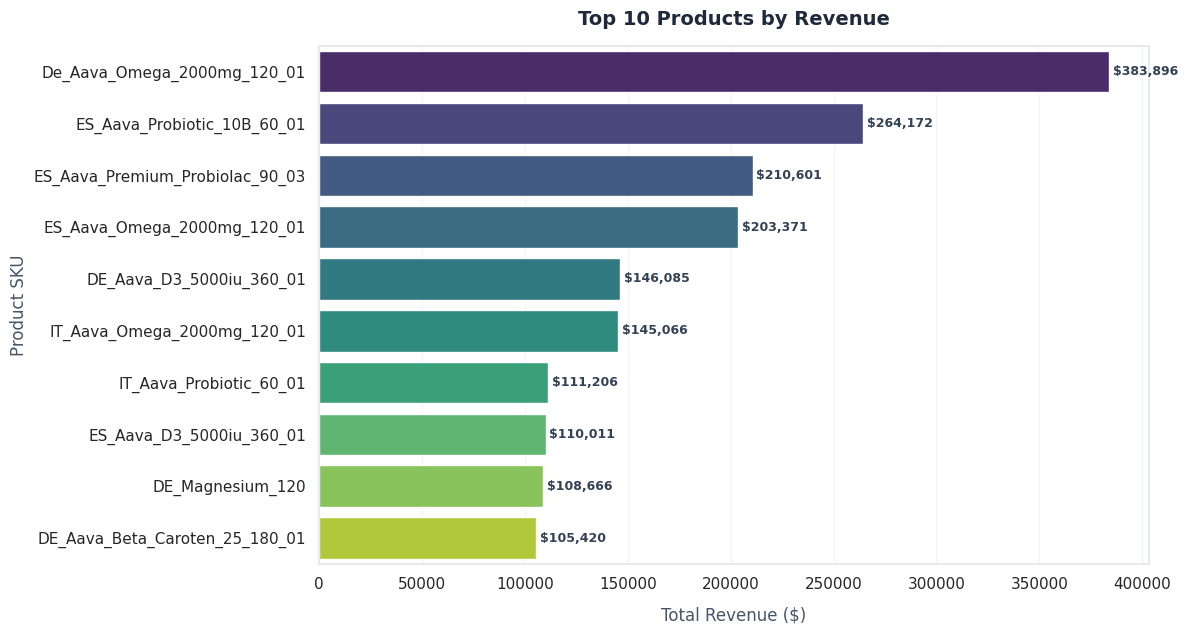

In [24]:
top10_rev = sku_summary.nlargest(10, "Total_Revenue")

plt.figure(figsize=(12, 6.5))
sns.barplot(
    data=top10_rev,
    y="SKU",
    x="Total_Revenue",
    palette="viridis",
    hue="SKU",
    legend=False
)

# Formatting labels
for index, value in enumerate(top10_rev["Total_Revenue"]):
    plt.text(value + (top10_rev["Total_Revenue"].max() * 0.005), index, f"${value:,.0f}",
             va='center', fontsize=9, fontweight='bold', color='#334155')

plt.title('Top 10 Products by Revenue', fontsize=14, fontweight='bold', pad=15, color='#1e293b')
plt.xlabel('Total Revenue ($)', fontsize=12, labelpad=10, color='#475569')
plt.ylabel('Product SKU', fontsize=12, color='#475569')
plt.tight_layout()
plt.show()

### Chart 2: Profit Pareto 80/20 Rule (Pareto Chart)
Analyze the concentration of Net Profits across products to verify if 80% of net profits are driven by 20% of SKUs.

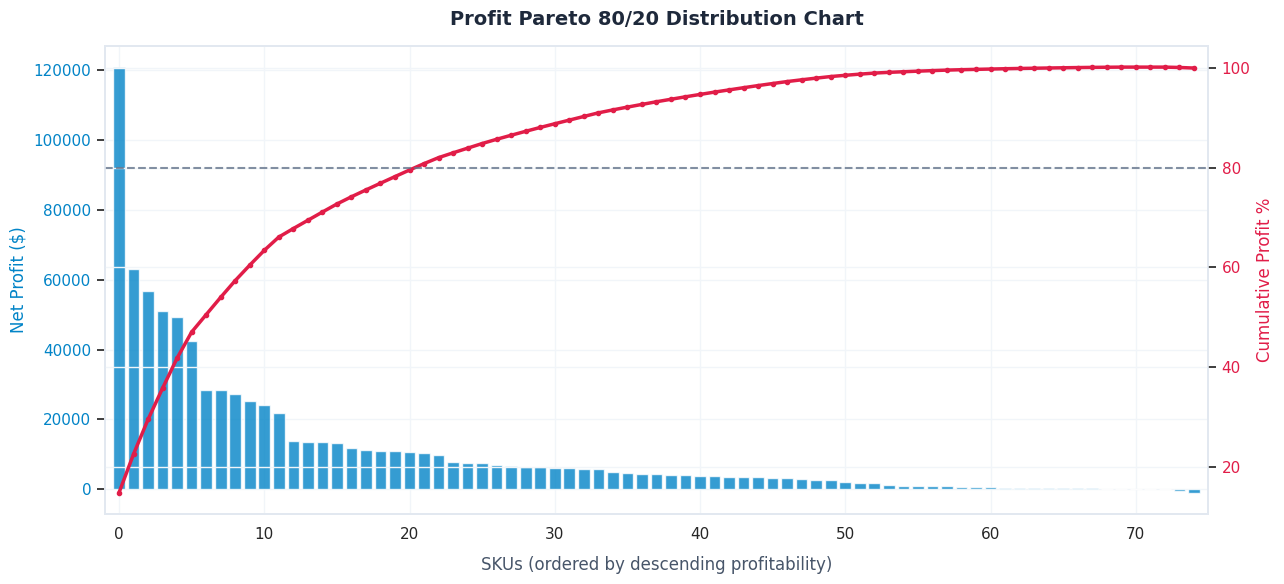

In [25]:
# Sort SKUs by net profit descending
pareto_df = sku_summary.sort_values(by="Total_Net_Profit", ascending=False).reset_index(drop=True)
pareto_df["Cumulative_Profit"] = pareto_df["Total_Net_Profit"].cumsum()
overall_profit = pareto_df["Total_Net_Profit"].sum()

# We normalize against positive profits or overall profit.
# If overall_profit is used, we plot cumulative contribution.
pareto_df["Cumulative_Profit_%"] = (pareto_df["Cumulative_Profit"] / overall_profit) * 100

fig, ax1 = plt.subplots(figsize=(13, 6))

# Individual profit bars
ax1.bar(pareto_df.index, pareto_df["Total_Net_Profit"], color="#0284c7", alpha=0.8, label="Net Profit")
ax1.set_xlabel("SKUs (ordered by descending profitability)", fontsize=12, labelpad=10, color="#475569")
ax1.set_ylabel("Net Profit ($)", color="#0284c7", fontsize=12)
ax1.tick_params(axis="y", labelcolor="#0284c7")
ax1.set_xlim(-1, len(pareto_df))

# Cumulative percentage curve
ax2 = ax1.twinx()
ax2.plot(pareto_df.index, pareto_df["Cumulative_Profit_%"], color="#e11d48", linewidth=2.5, marker="o", markersize=3, label="Cumulative Profit %")
ax2.set_ylabel("Cumulative Profit %", color="#e11d48", fontsize=12)
ax2.tick_params(axis="y", labelcolor="#e11d48")
ax2.axhline(80, color="#64748b", linestyle="--", linewidth=1.5, alpha=0.8, label="80% Profit line")

plt.title("Profit Pareto 80/20 Distribution Chart", fontsize=14, fontweight="bold", pad=15, color="#1e293b")
fig.tight_layout()
plt.show()

### Chart 3: The "Vanity vs. Sanity" Matrix (Scatter Plot)
Compare top-line **Revenue** (Vanity) against **Net Margin %** (Sanity). Bubble size represents **Total Units Sold**, and color maps to **Total Net Profit**.

*This chart isolates high-revenue, low-margin products (False Positives) and low-revenue, high-margin opportunities (Hidden Gems).*

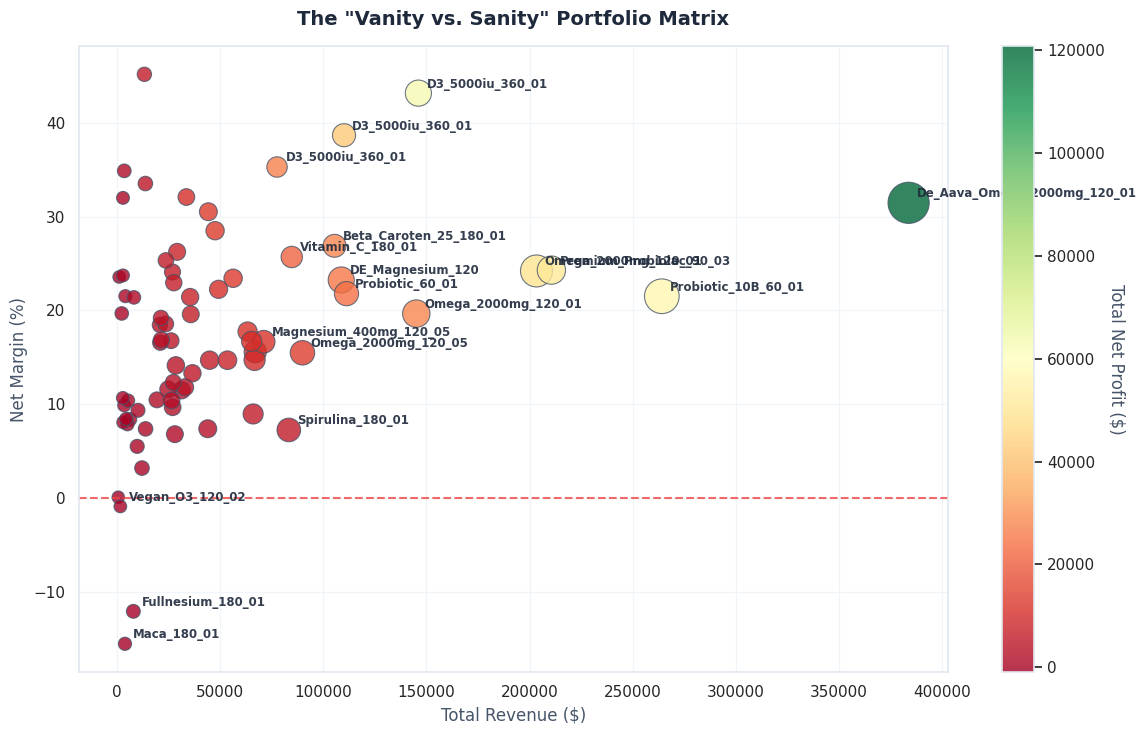

In [26]:
plt.figure(figsize=(12, 7.5))

# Size mapping normalized for readability
max_units = sku_summary["Total_Units"].max()
size_scale = (sku_summary["Total_Units"] / max_units) * 800 + 80

# Color mapping based on Net Profit
scatter = plt.scatter(
    sku_summary["Total_Revenue"],
    sku_summary["Net_Margin_%"],
    s=size_scale,
    c=sku_summary["Total_Net_Profit"],
    cmap="RdYlGn",
    alpha=0.8,
    edgecolors="#475569",
    linewidths=0.8
)

# Label outliers and notable SKUs
for i, row in sku_summary.iterrows():
    # Label if SKU is in top 15% revenue or has negative margin
    if row["Total_Revenue"] > sku_summary["Total_Revenue"].quantile(0.8) or row["Net_Margin_%"] < 0:
        clean_label = row["SKU"].replace("UK_Aava_", "").replace("DE_Aava_", "").replace("FR_Aava_", "").replace("IT_Aava_", "").replace("ES_Aava_", "")
        plt.annotate(
            clean_label,
            (row["Total_Revenue"], row["Net_Margin_%"]),
            xytext=(6, 4),
            textcoords="offset points",
            fontsize=8.5,
            fontweight="semibold",
            color="#1e293b",
            alpha=0.9
        )

plt.axhline(0, color="#ef4444", linestyle="--", linewidth=1.5, alpha=0.8)
plt.title('The "Vanity vs. Sanity" Portfolio Matrix', fontsize=14, fontweight='bold', pad=15, color='#1e293b')
plt.xlabel('Total Revenue ($)', fontsize=12, color='#475569')
plt.ylabel('Net Margin (%)', fontsize=12, color='#475569')

# Add legend colorbar
cbar = plt.colorbar(scatter)
cbar.set_label('Total Net Profit ($)', rotation=270, labelpad=15, color='#475569')
plt.tight_layout()
plt.show()

### Chart 4: Margin Erosion by SKU (100% Stacked Bar)
For the **Top 10 Products by Revenue**, show how costs (COGS, FBA Fees, PPC Costs, Taxes) erode the gross revenue, displaying the remaining Net Margin %.

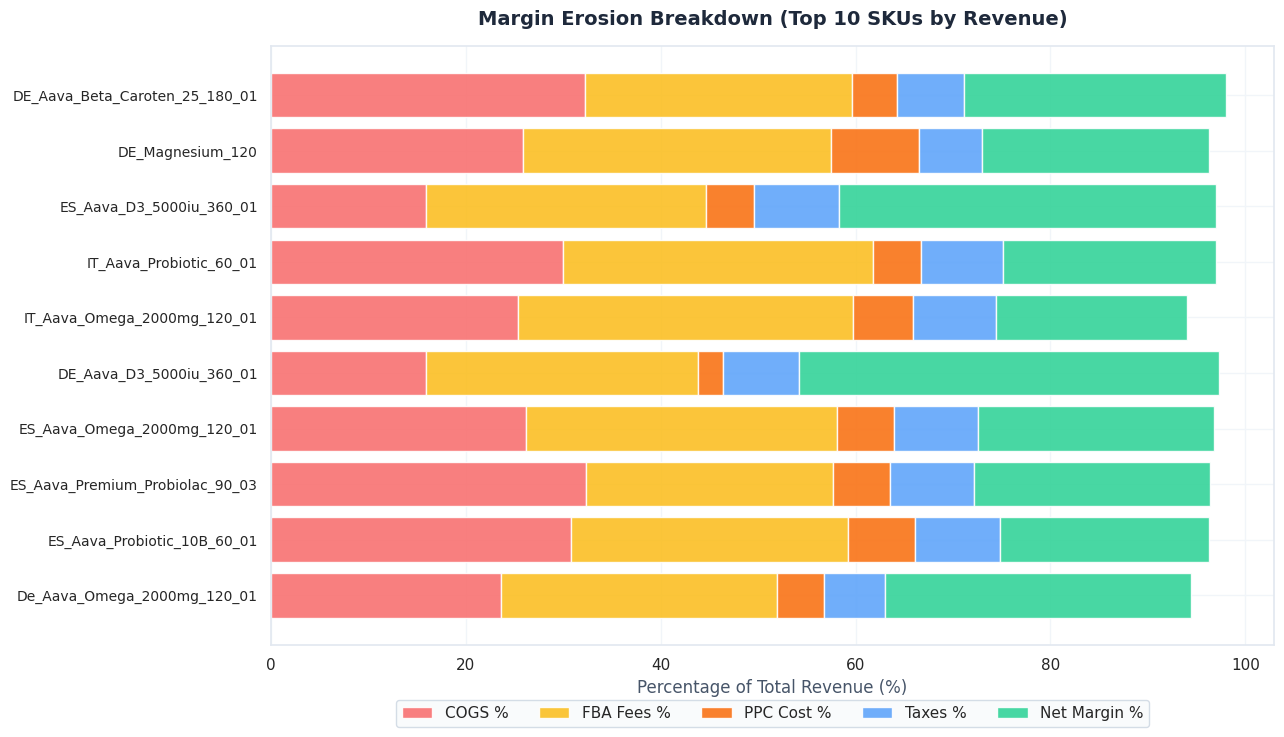

In [27]:
top10_skus = sku_summary.nlargest(10, "Total_Revenue").copy()

# Calculate percentages relative to Total Revenue
top10_skus["COGS_%"] = (top10_skus["Total_COGS"] / top10_skus["Total_Revenue"]) * 100
top10_skus["FBA_%"] = (top10_skus["Total_FBA"] / top10_skus["Total_Revenue"]) * 100
top10_skus["PPC_%"] = (top10_skus["Total_PPC"] / top10_skus["Total_Revenue"]) * 100
top10_skus["Taxes_%"] = (top10_skus["Total_Taxes"] / top10_skus["Total_Revenue"]) * 100

# Stacking values for 100% chart visualization
y_pos = np.arange(len(top10_skus))
labels = top10_skus["SKU"].values

cogs = top10_skus["COGS_%"].values
fba = top10_skus["FBA_%"].values
ppc = top10_skus["PPC_%"].values
taxes = top10_skus["Taxes_%"].values
margin = top10_skus["Net_Margin_%"].values

plt.figure(figsize=(13, 7.5))

plt.barh(y_pos, cogs, label="COGS %", color="#f87171", alpha=0.9)
plt.barh(y_pos, fba, left=cogs, label="FBA Fees %", color="#fbbf24", alpha=0.9)
plt.barh(y_pos, ppc, left=cogs+fba, label="PPC Cost %", color="#f97316", alpha=0.9)
plt.barh(y_pos, taxes, left=cogs+fba+ppc, label="Taxes %", color="#60a5fa", alpha=0.9)
plt.barh(y_pos, margin, left=cogs+fba+ppc+taxes, label="Net Margin %", color="#34d399", alpha=0.9)

plt.yticks(y_pos, labels, fontsize=10)
plt.xlabel("Percentage of Total Revenue (%)", fontsize=12, color="#475569")
plt.title("Margin Erosion Breakdown (Top 10 SKUs by Revenue)", fontsize=14, fontweight="bold", pad=15, color="#1e293b")
plt.legend(loc="lower center", bbox_to_anchor=(0.5, -0.15), ncol=5, frameon=True, facecolor="#f8fafc", edgecolor="#cbd5e1")
plt.tight_layout()
plt.show()

### Chart 5: Bleeding SKUs Alert (Data Table)
Identify products with negative Net Profit. Includes critical metrics: Net Margin %, TACoS % (Total Ad Cost of Sales), Refund Rate %, and FBA Fees.

In [28]:
# Refund rate per SKU (Total_Refunds and Total_Units already computed in
# the sku_summary aggregation above — no need to recompute/re-merge them,
# which previously caused a column name collision: "Total_Refunds" would
# exist in both frames being merged, so pandas silently renamed them to
# "Total_Refunds_x"/"Total_Refunds_y" and the code below crashed with a
# KeyError looking for the now-missing plain "Total_Refunds" column.)
sku_summary["Refund_Rate_%"] = (sku_summary["Total_Refunds"] / sku_summary["Total_Units"]) * 100

# Filter for Bleeding SKUs (Net Profit < 0)
bleeding_skus = sku_summary[sku_summary["Total_Net_Profit"] < 0].copy()

# Select alert fields
alert_table = bleeding_skus[[
    "SKU", "Total_Revenue", "Total_Net_Profit", "Net_Margin_%", "TACoS_%", "Refund_Rate_%", "Total_FBA"
]].sort_values(by="Total_Net_Profit")

print("="*100)
print("                           BLEEDING SKUS ALERT: CRITICAL CASH DRAINS")
print("="*100)
if len(alert_table) == 0:
    print("All products are generating positive net profit. No bleeding SKUs detected.")
else:
    print(alert_table.to_string(index=False, formatters={
        'Total_Revenue': '${:,.2f}'.format,
        'Total_Net_Profit': '${:,.2f}'.format,
        'Net_Margin_%': '{:.2f}%'.format,
        'TACoS_%': '{:.2f}%'.format,
        'Refund_Rate_%': '{:.2f}%'.format,
        'Total_FBA': '${:,.2f}'.format
    }))
print("="*100)


                           BLEEDING SKUS ALERT: CRITICAL CASH DRAINS
                      SKU Total_Revenue Total_Net_Profit Net_Margin_% TACoS_% Refund_Rate_% Total_FBA
IT_Aava_Fullnesium_180_01     $7,810.30         $-942.29      -12.06%  15.33%         0.88% $2,928.81
      UK_Aava_Maca_180_01     $3,736.74         $-580.03      -15.52%   0.31%         0.42% $1,116.44
  FR_Aava_Vegan_O3_120_02     $1,498.74          $-13.29       -0.89%  13.01%         0.00%   $552.04


## 5. Strategic Recommendations
Based on the analysis:
1. **Prune/Reprice Bleeding SKUs:** Examine SKUs in the Bleeding SKU alert list. If TACoS is extremely high, freeze or optimize PPC bids. If Refund Rate is high (>10%), audit physical quality control.
2. **Defend Star Performers:** Secure stock levels for top revenue earners with strong margins.
3. **Address Margin Erosion:** Identify where FBA fees or PPC spend are disproportionately high and optimize packaging dimensions/weight.

---
# DASHBOARD 3: Revenue & Marketplace Trends

_Revenue trends over time, marketplace comparisons, seasonal patterns._

---

EDA for Dashboard 3

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

> **Data Note:** This section uses `df` (the fully-joined Star Schema table), plus `fact_sales`, `dim_date`, `dim_product`, and `dim_market` (raw tables) and the aliases `df_merged` / `sales` — all loaded once in **Section 0** above. No separate loading needed.


In [30]:
fact_sales.columns

Index(['Sales_Key', 'Date_ID', 'Market_ID', 'SKU_ID', 'Account Title', 'Taxes',
       'Orders', 'Units', 'Refunded', 'Refund %', 'Unit Session %',
       'Promo Units', 'Organic Units', 'Per Unit Revenue', 'Revenue', 'COGS',
       'FBA Fees', 'Promo Amount', 'Sessions', 'Page Views', 'Impressions',
       'Clicks', 'PPC Orders', 'PPC Sales', 'PPC Cost', 'PPC Conv', 'OOE',
       'Net Profit', 'Net Margin', 'Net ROI'],
      dtype='object')

In [31]:
dim_market.columns

Index(['Market_ID', 'Market Place', 'Account Title'], dtype='object')

In [32]:
dim_date.columns

Index(['Date_ID', 'Date', 'Day', 'Month', 'Quarter', 'Year'], dtype='object')

In [33]:
dim_product.columns

Index(['SKU_ID', 'SKU', 'FNSKU', 'ASIN', 'Parent ASIN', 'Is Parent', 'Brand',
       'Title'],
      dtype='object')

In [34]:
# NOTE: df is already the fully-joined Fact + all-Dimensions table loaded
# in Section 0 (Star_Schema sheet) — no re-merge needed here.
# (The original re-merge attempt used key names — 'Marketplace_Key',
# 'Date_Key', 'Product_Key' — that don't exist in this dataset and would
# raise a KeyError; the real keys are 'Market_ID', 'Date_ID', 'SKU_ID',
# and the join was already performed upstream in the Gold Layer.)

print("Using pre-merged df from Section 0:", df.shape)


Using pre-merged df from Section 0: (13323, 47)


In [35]:
print("Rows:",df.shape[0])
print("Columns:",df.shape[1])

Rows: 13323
Columns: 47


In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13323 entries, 0 to 13322
Data columns (total 47 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Sales_Key          13323 non-null  int64         
 1   Date_ID            13323 non-null  int64         
 2   Market_ID          13323 non-null  int64         
 3   SKU_ID             13323 non-null  int64         
 4   Account Title      13323 non-null  object        
 5   Taxes              13323 non-null  float64       
 6   Orders             13323 non-null  int64         
 7   Units              13323 non-null  int64         
 8   Refunded           13323 non-null  int64         
 9   Refund %           13323 non-null  float64       
 10  Unit Session %     13323 non-null  float64       
 11  Promo Units        13323 non-null  int64         
 12  Organic Units      13323 non-null  int64         
 13  Per Unit Revenue   13323 non-null  float64       
 14  Revenu

In [37]:
df.isnull().sum()

,0
Sales_Key,0
Date_ID,0
Market_ID,0
SKU_ID,0
Account Title,0
Taxes,0
Orders,0
Units,0
Refunded,0
Refund %,0


1-Revenue Analysis

In [38]:
total_revenue = df['Revenue'].sum()

print("Total Revenue =",total_revenue)

Total Revenue = 3628133.7699999996


In [39]:
revenue_market = (
    df.groupby('Market Place')['Revenue']
    .sum()
    .sort_values(ascending=False)
)

revenue_market

,Revenue
Market Place,
DE,"1,151,257.96"
ES,"1,111,192.69"
IT,"589,495.20"
UK,"566,358.12"
FR,"209,829.80"


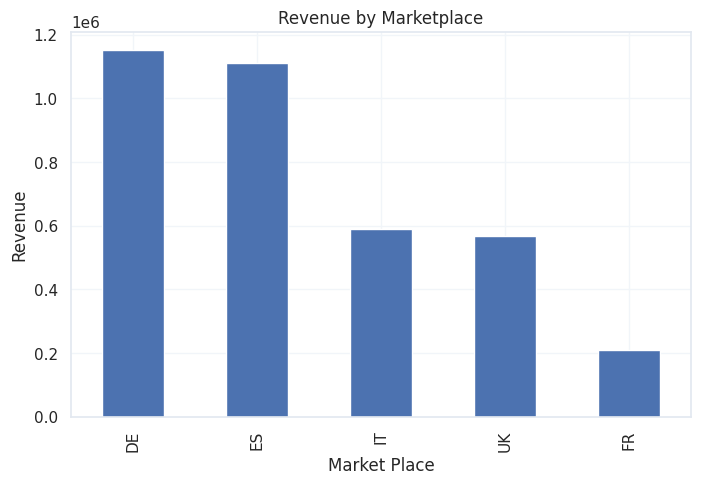

In [40]:
plt.figure(figsize=(8,5))

revenue_market.plot(kind='bar')

plt.title("Revenue by Marketplace")
plt.ylabel("Revenue")

plt.show()

2-Orders Analysis

In [41]:
orders_market = (
    df.groupby('Market Place')['Orders']
    .sum()
    .sort_values(ascending=False)
)

orders_market

,Orders
Market Place,
DE,45988
ES,45381
UK,27396
IT,23919
FR,8480


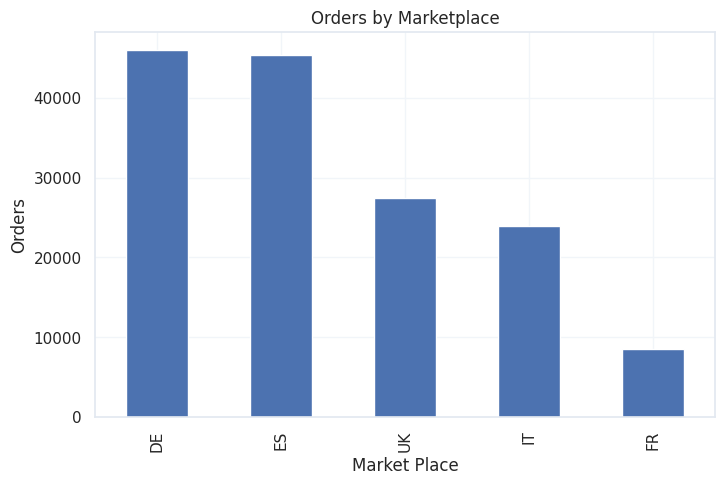

In [42]:
plt.figure(figsize=(8,5))

orders_market.plot(kind='bar')

plt.title("Orders by Marketplace")
plt.ylabel("Orders")

plt.show()

3-Units Sold Analysis

In [43]:
units_market = (
    df.groupby('Market Place')['Units']
    .sum()
    .sort_values(ascending=False)
)

units_market

,Units
Market Place,
DE,55390
ES,52445
UK,30880
IT,28012
FR,10450


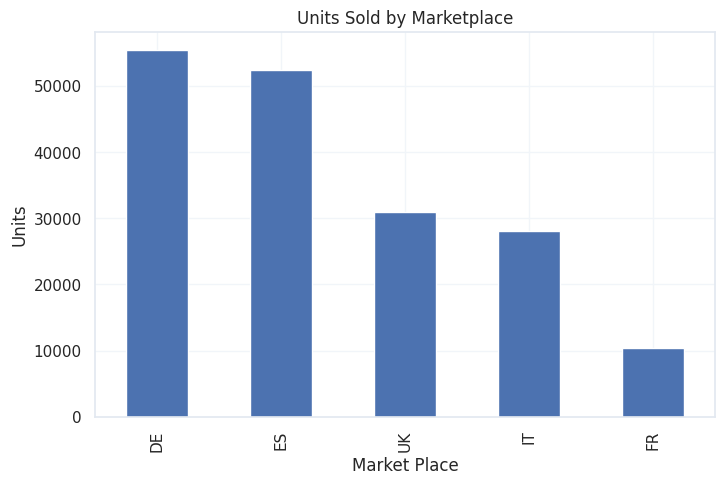

In [44]:
plt.figure(figsize=(8,5))

units_market.plot(kind='bar')

plt.title("Units Sold by Marketplace")
plt.ylabel("Units")

plt.show()

4-Net Profit Analysis

In [45]:
profit_market = (
    df.groupby('Market Place')['Net Profit']
    .sum()
    .sort_values(ascending=False)
)

profit_market

,Net Profit
Market Place,
DE,"333,395.70"
ES,"260,852.48"
IT,"105,717.83"
UK,"78,125.58"
FR,"37,598.64"


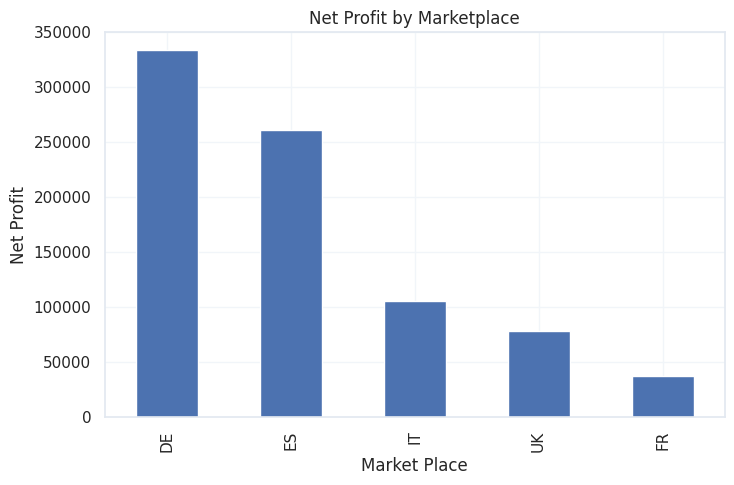

In [46]:
plt.figure(figsize=(8,5))

profit_market.plot(kind='bar')

plt.title("Net Profit by Marketplace")
plt.ylabel("Net Profit")

plt.show()

5-Average Net Margin

In [47]:
margin_market = (
    df.groupby('Market Place')['Net Margin']
    .mean()
    .sort_values(ascending=False)
)

margin_market

,Net Margin
Market Place,
DE,0.24
ES,0.20
UK,0.13
FR,0.12
IT,0.11


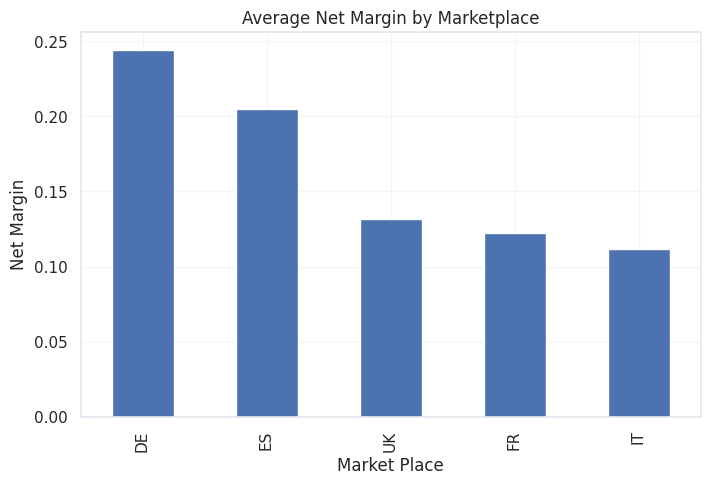

In [48]:
plt.figure(figsize=(8,5))

margin_market.plot(kind='bar')

plt.title("Average Net Margin by Marketplace")
plt.ylabel("Net Margin")

plt.show()

6-Revenue Contribution

In [49]:
market_share = (
    df.groupby('Market Place')['Revenue']
    .sum()
)

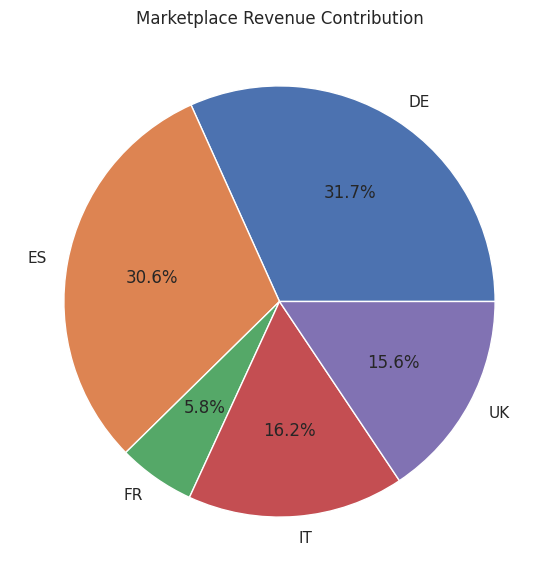

In [50]:
plt.figure(figsize=(7,7))

market_share.plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title("Marketplace Revenue Contribution")
plt.ylabel("")

plt.show()

7-Revenue Trend Over Time

In [51]:
monthly_revenue = (
    df.groupby(['Year','Month'])['Revenue']
    .sum()
)
monthly_revenue

Year  Month
2020  10      556,418.12
      11      567,418.18
      12      421,130.36
2021  1       561,266.13
      2       496,282.89
      3       553,953.23
      4       471,664.86
Name: Revenue, dtype: float64

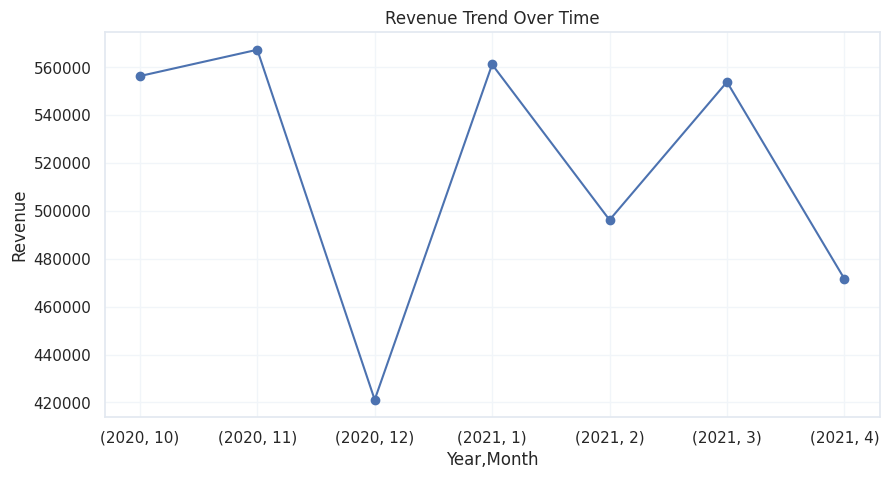

In [52]:
monthly_revenue.plot(
    figsize=(10,5),
    marker='o'
)

plt.title("Revenue Trend Over Time")
plt.ylabel("Revenue")

plt.show()

8-Best Marketplace

In [53]:
best_market = (
    df.groupby('Market Place')['Revenue']
    .sum()
    .idxmax()
)

print("Best Marketplace =",best_market)

Best Marketplace = DE


9-ROI by Marketplace

In [54]:
roi_market = (
    df.groupby('Market Place')['Net ROI']
    .mean()
    .sort_values(ascending=False)
)

roi_market

,Net ROI
Market Place,
DE,0.45
ES,0.39
UK,0.19
FR,0.19
IT,0.19


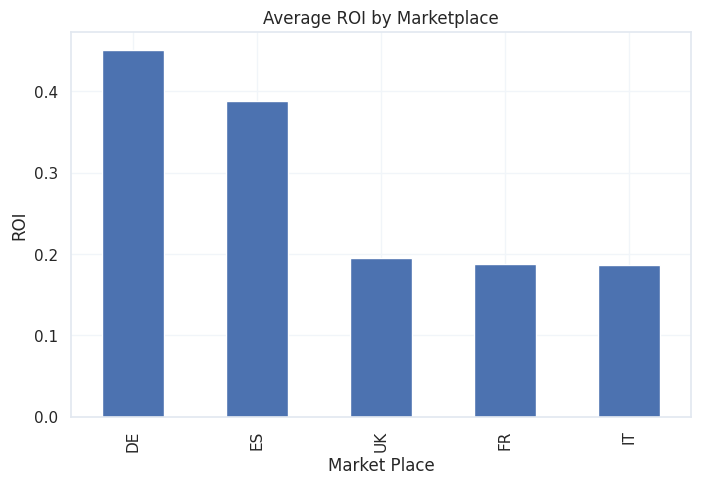

In [55]:
plt.figure(figsize=(8,5))

roi_market.plot(kind='bar')

plt.title("Average ROI by Marketplace")
plt.ylabel("ROI")

plt.show()

10-Multi-Marketplace Performance Trend

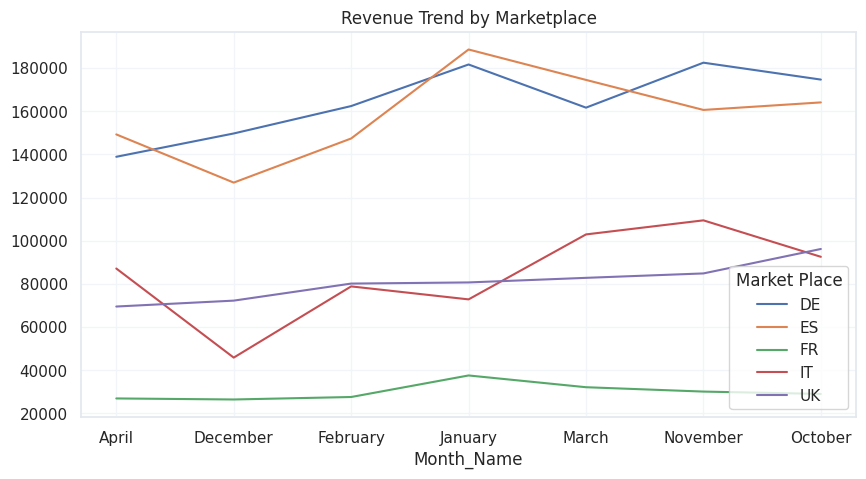

In [56]:
trend = df.groupby(['Month_Name','Market Place'])['Revenue'].sum().unstack()
trend.plot(figsize=(10,5))
plt.title("Revenue Trend by Marketplace")
plt.show()

11-Profitability by Day of Week

In [57]:
heatmap_data = df.pivot_table(
    values='Net Profit',
    index='Market Place',
    columns='Day_Name',
    aggfunc='sum'
)

heatmap_data

Day_Name,Friday,Monday,Saturday,Sunday,Thursday,Tuesday,Wednesday
Market Place,,,,,,,
DE,"41,017.14","56,244.78","39,384.05","52,741.96","46,754.28","49,452.73","47,800.76"
ES,"32,711.43","42,986.97","31,575.51","39,874.20","37,159.41","38,887.31","37,657.65"
FR,"4,849.73","6,102.18","4,839.99","5,527.20","5,174.45","5,507.14","5,597.95"
IT,"12,648.40","17,838.11","13,418.24","16,332.39","15,080.67","15,340.25","15,059.77"
UK,"11,222.56","12,583.94","10,805.00","12,117.46","11,646.50","10,164.45","9,585.67"


12-Cost Breakdown by Marketplace

In [58]:
costs = df.groupby('Market Place')[
    ['COGS','FBA Fees','PPC Cost','Net Profit']
].sum()

costs

,COGS,FBA Fees,PPC Cost,Net Profit
Market Place,,,,
DE,"302,104.42","323,982.95","59,727.71","333,395.70"
ES,"318,847.72","326,787.65","70,939.33","260,852.48"
FR,"62,106.41","75,575.96","12,471.72","37,598.64"
IT,"170,817.44","193,746.67","32,602.67","105,717.83"
UK,"216,612.22","172,932.10","27,391.35","78,125.58"


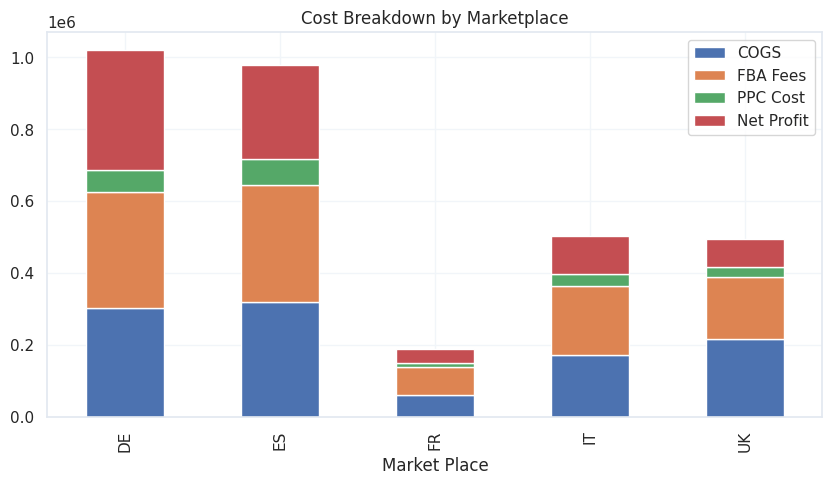

In [59]:
costs.plot(
    kind='bar',
    stacked=True,
    figsize=(10,5)
)

plt.title("Cost Breakdown by Marketplace")
plt.show()

---
#  DASHBOARD 4: Marketing & PPC Analysis

_Sessions, CTR, PPC Spend vs. Sales, conversion rates, marketing funnel, halo effect._

---

Import **Libraries**

In [60]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
sns.set(font_scale=1.1)

Load Data

> **Data Note:** This section uses `df` (the fully-joined Star Schema table), plus `fact_sales`, `dim_date`, `dim_product`, and `dim_market` (raw tables) and the aliases `df_merged` / `sales` — all loaded once in **Section 0** above. No separate loading needed.


Merge Tables

In [61]:
# NOTE: df is already the fully-joined Fact + all-Dimensions table loaded
# in Section 0 (Star_Schema sheet) — no re-merge needed here.
# (The original code referenced undefined variables `fact`, `product`,
# `market`, `date` and would raise a NameError.)

print("Using pre-merged df from Section 0:", df.shape)


Using pre-merged df from Section 0: (13323, 47)


Dataset Overview

In [62]:
print("="*60)
print("Marketing Dataset Overview")
print("="*60)

print(f"Dataset Shape : {df.shape}")

print("\nFirst 5 Rows")
display(df.head())

print("\nDataset Information")
df.info()

Marketing Dataset Overview
Dataset Shape : (13323, 47)

First 5 Rows


,Sales_Key,Date_ID,Market_ID,SKU_ID,Account Title,Taxes,Orders,Units,Refunded,Refund %,...,ASIN,Parent ASIN,Is Parent,Brand,Title,Market Place,Account Title_mkt,Month_Name,Day_Name,Month_Year
0,1,1,1,1,[ UK ] Aava,50.34,17,17,0,0.00,...,B01GU9QLZC,No Parent,0,Aavalabs,High Absorption Magnesium Citrate Supplements ...,UK,[ UK ] Aava,October,Thursday,2020-October
1,2,2,1,1,[ UK ] Aava,58.89,20,20,0,0.00,...,B01GU9QLZC,No Parent,0,Aavalabs,High Absorption Magnesium Citrate Supplements ...,UK,[ UK ] Aava,October,Friday,2020-October
2,3,3,1,1,[ UK ] Aava,72.41,18,24,0,0.00,...,B01GU9QLZC,No Parent,0,Aavalabs,High Absorption Magnesium Citrate Supplements ...,UK,[ UK ] Aava,October,Saturday,2020-October
3,4,4,1,1,[ UK ] Aava,41.43,13,14,0,0.00,...,B01GU9QLZC,No Parent,0,Aavalabs,High Absorption Magnesium Citrate Supplements ...,UK,[ UK ] Aava,October,Sunday,2020-October
4,5,5,1,1,[ UK ] Aava,47.04,16,16,0,0.00,...,B01GU9QLZC,No Parent,0,Aavalabs,High Absorption Magnesium Citrate Supplements ...,UK,[ UK ] Aava,October,Monday,2020-October



Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13323 entries, 0 to 13322
Data columns (total 47 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Sales_Key          13323 non-null  int64         
 1   Date_ID            13323 non-null  int64         
 2   Market_ID          13323 non-null  int64         
 3   SKU_ID             13323 non-null  int64         
 4   Account Title      13323 non-null  object        
 5   Taxes              13323 non-null  float64       
 6   Orders             13323 non-null  int64         
 7   Units              13323 non-null  int64         
 8   Refunded           13323 non-null  int64         
 9   Refund %           13323 non-null  float64       
 10  Unit Session %     13323 non-null  float64       
 11  Promo Units        13323 non-null  int64         
 12  Organic Units      13323 non-null  int64         
 13  Per Unit Revenue   13323 non-null  float

Marketing Statistics

In [63]:


marketing_cols = [
    "Sessions",
    "Clicks",
    "Impressions",
    "PPC Cost",
    "PPC Sales",
    "Organic Units",
    "PPC Conv",
    "Unit Session %"
]

stats = df[marketing_cols].describe().T

display(stats)

,count,mean,std,min,25%,50%,75%,max
Sessions,"13,323.00",20.97,41.50,0.00,0.00,0.00,25.00,431.00
Clicks,"13,323.00",15.58,25.22,0.00,2.00,7.00,18.00,713.00
Impressions,"13,323.00","4,165.73","6,593.38",0.00,537.00,"1,917.00","5,036.50","121,882.00"
PPC Cost,"13,323.00",15.25,26.14,0.00,1.14,6.33,17.23,"1,064.85"
PPC Sales,"13,323.00",51.90,94.22,0.00,0.00,18.17,63.61,"2,875.44"
Organic Units,"13,323.00",13.28,20.22,0.00,3.00,7.00,16.00,974.00
PPC Conv,"13,323.00",0.14,0.26,0.00,0.00,0.08,0.20,6.00
Unit Session %,"13,323.00",0.13,0.22,0.00,0.00,0.00,0.25,7.00


#KPIS



 Total Sessions


In [64]:
total_sessions = df['Sessions'].sum()

print(f"Total Sessions: {total_sessions:,.0f}")

Total Sessions: 279,357


Average CTR

In [65]:
avg_ctr = (
    df['Clicks'].sum() / df['Impressions'].sum() * 100
    if df['Impressions'].sum() != 0 else 0
)

print(f"Average CTR: {avg_ctr:.2f}%")

Average CTR: 0.37%


Total PPC Spend

In [66]:
total_ppc_spend = df['PPC Cost'].sum()

print(f"Total PPC Spend: ${total_ppc_spend:,.2f}")

Total PPC Spend: $203,132.78


Total PPC Sales

In [67]:
total_ppc_sales = df['PPC Sales'].sum()

print(f"Total PPC Sales: ${total_ppc_sales:,.2f}")

Total PPC Sales: $691,398.06


Average Conversion Rate

In [68]:
avg_conversion_rate = df['Unit Session %'].mean()

print(f"Average Conversion Rate: {avg_conversion_rate:.2f}%")

Average Conversion Rate: 0.13%


#Correlation

Marketing Correlation Matrix

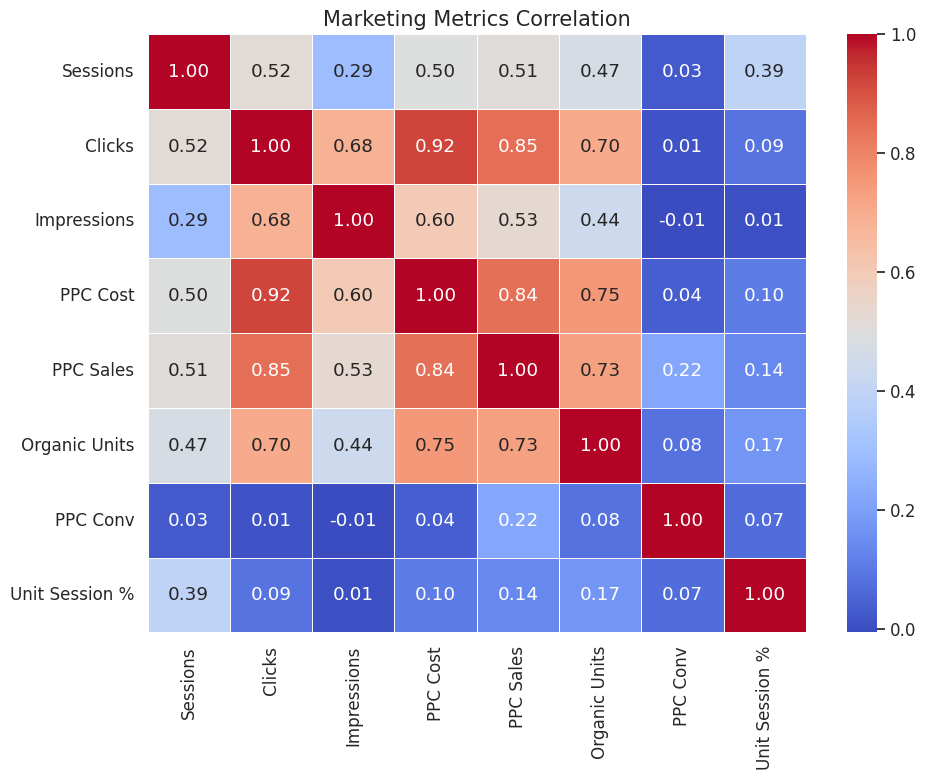

In [69]:


plt.figure(figsize=(10,8))

corr = df[marketing_cols].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Marketing Metrics Correlation", fontsize=15)

plt.tight_layout()

plt.show()

# Charts


Top 10 Products by PPC Sales

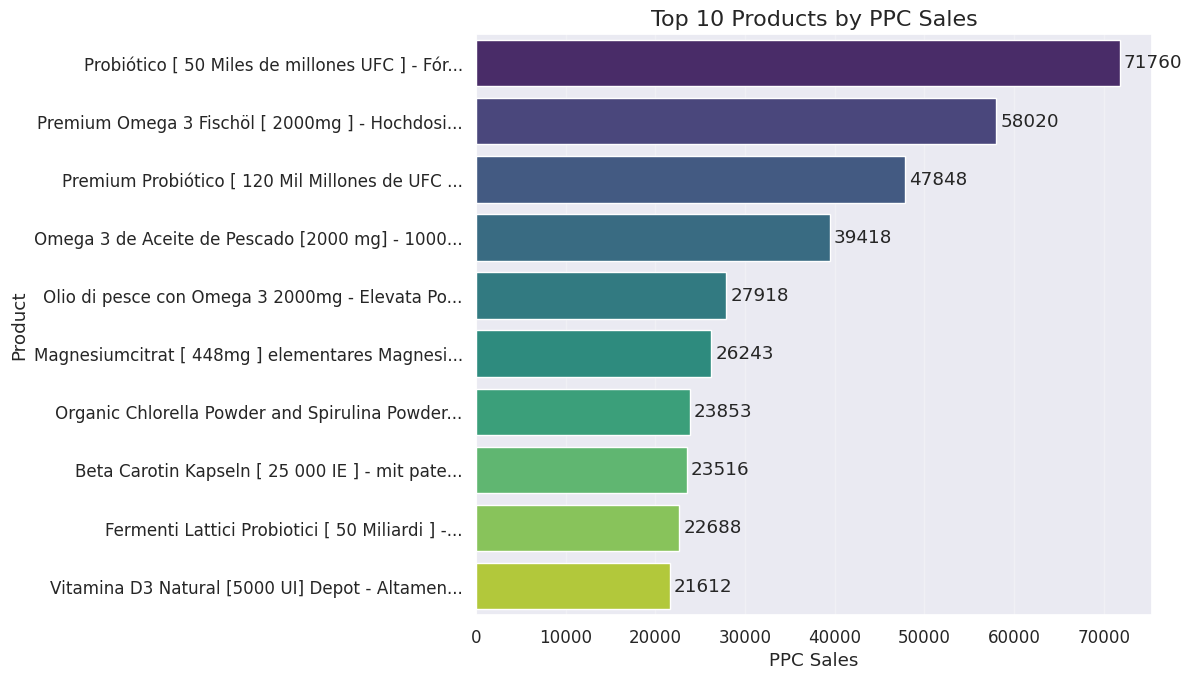

In [70]:
top_products = (
    df.groupby("Title", as_index=False)["PPC Sales"]
      .sum()
      .sort_values(by="PPC Sales", ascending=False)
      .head(10)
)


top_products["Short Title"] = top_products["Title"].apply(
    lambda x: x[:45] + "..." if len(x) > 45 else x
)

plt.figure(figsize=(12,7))

ax = sns.barplot(
    data=top_products,
    x="PPC Sales",
    y="Short Title",
    hue="Short Title",
    palette="viridis",
    legend=False
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=3)

plt.title("Top 10 Products by PPC Sales", fontsize=16)
plt.xlabel("PPC Sales")
plt.ylabel("Product")

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()

plt.show()

 Traffic vs Conversion Quadrants

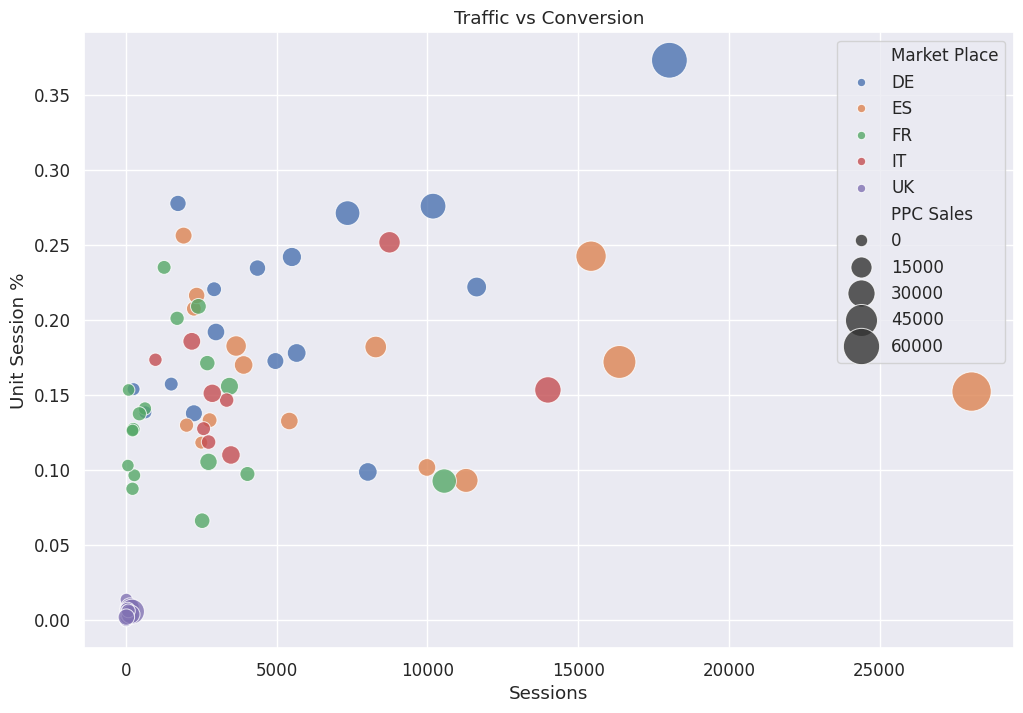

In [71]:
traffic = df.groupby("SKU").agg({
    "Sessions":"sum",
    "Unit Session %":"mean",
    "PPC Sales":"sum",
    "Market Place":"first"
}).reset_index()

plt.figure(figsize=(12,8))

sns.scatterplot(
    data=traffic,
    x="Sessions",
    y="Unit Session %",
    hue="Market Place",
    size="PPC Sales",
    sizes=(80,800),
    alpha=0.8
)

plt.title("Traffic vs Conversion")
plt.xlabel("Sessions")
plt.ylabel("Unit Session %")
plt.grid(True)

plt.show()

Halo Effect

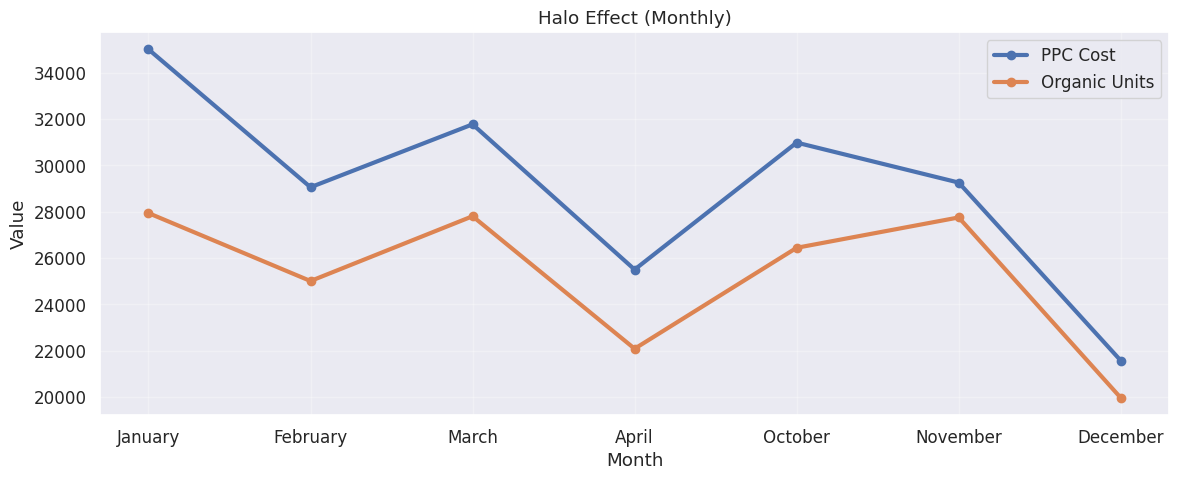

In [72]:
halo = df.groupby("Month_Name").agg({
    "PPC Cost":"sum",
    "Organic Units":"sum"
}).reset_index()

month_order = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

halo["Month_Name"] = pd.Categorical(
    halo["Month_Name"],
    categories=month_order,
    ordered=True
)

halo = halo.sort_values("Month_Name")

plt.figure(figsize=(12,5))

plt.plot(
    halo["Month_Name"],
    halo["PPC Cost"].abs(),
    marker="o",
    linewidth=3,
    label="PPC Cost"
)

plt.plot(
    halo["Month_Name"],
    halo["Organic Units"],
    marker="o",
    linewidth=3,
    label="Organic Units"
)

plt.title("Halo Effect (Monthly)")
plt.xlabel("Month")
plt.ylabel("Value")
plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Marketing Funnel

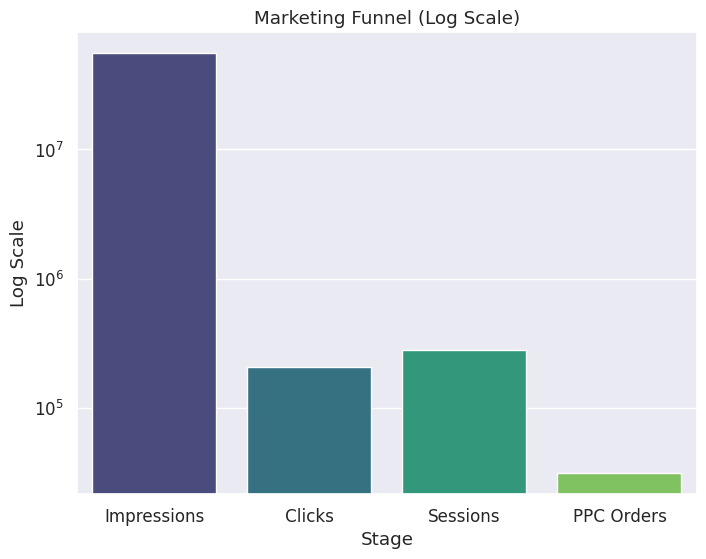

In [73]:
funnel = pd.DataFrame({
    "Stage": ["Impressions", "Clicks", "Sessions", "PPC Orders"],
    "Value": [
        df["Impressions"].sum(),
        df["Clicks"].sum(),
        df["Sessions"].sum(),
        df["PPC Orders"].sum()
    ]
})

plt.figure(figsize=(8,6))

sns.barplot(
    data=funnel,
    x="Stage",
    y="Value",
    hue="Stage",
    palette="viridis",
    legend=False
)

plt.yscale("log")
plt.title("Marketing Funnel (Log Scale)")
plt.ylabel("Log Scale")

plt.show()

PPC Efficiency by Marketplace

<Figure size 1200x600 with 0 Axes>

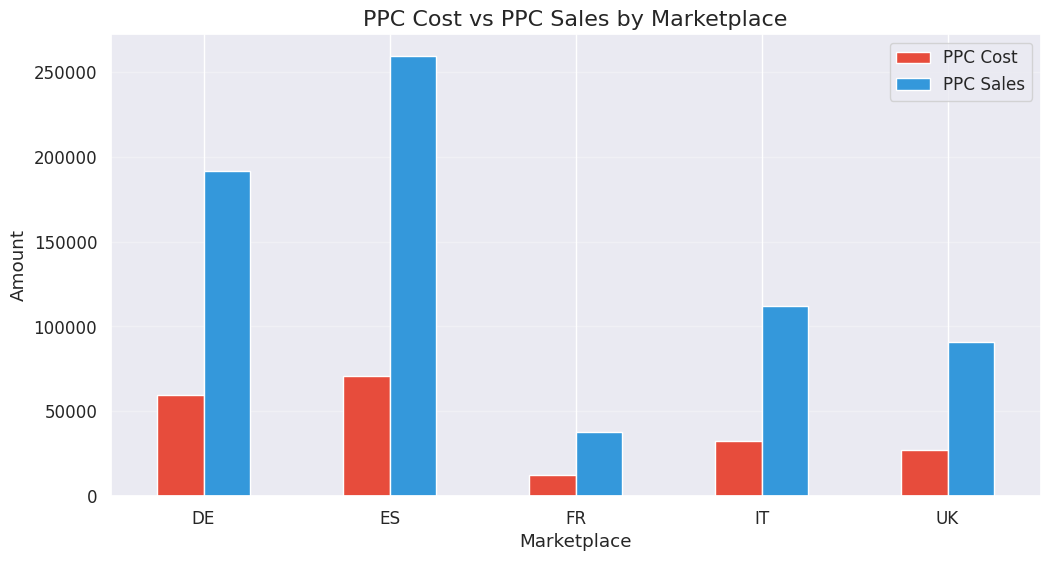

In [74]:
marketplace = df.groupby("Market Place").agg({
    "PPC Cost":"sum",
    "PPC Sales":"sum"
}).reset_index()

marketplace["PPC Cost"] = marketplace["PPC Cost"].abs()

plt.figure(figsize=(12,6))

marketplace.plot(
    x="Market Place",
    y=["PPC Cost","PPC Sales"],
    kind="bar",
    figsize=(12,6),
    color=["#E74C3C","#3498DB"]
)

plt.title("PPC Cost vs PPC Sales by Marketplace", fontsize=16)
plt.xlabel("Marketplace")
plt.ylabel("Amount")
plt.xticks(rotation=0)

plt.grid(axis="y", alpha=0.3)

plt.show()

PPC Cost vs PPC Conversion

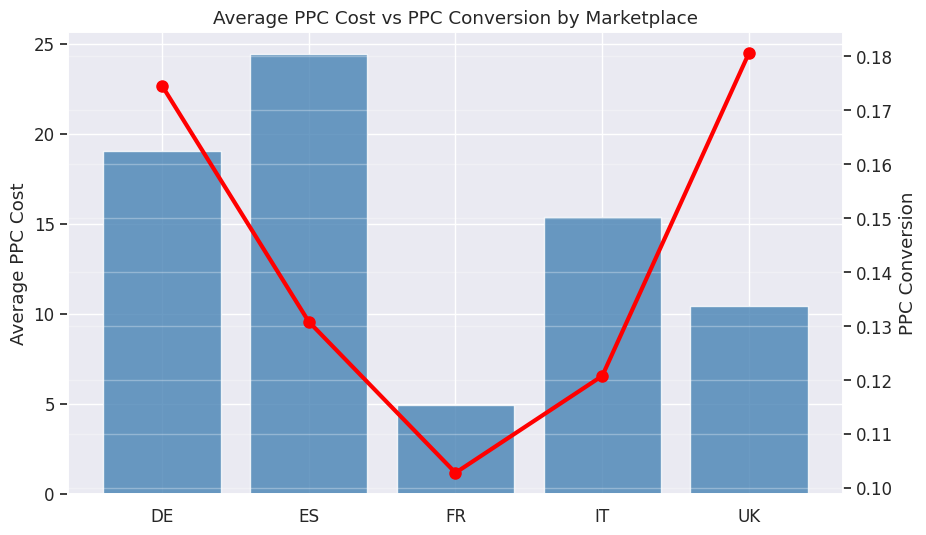

In [75]:
trend = df.groupby("Market Place").agg({
    "PPC Cost":"mean",
    "PPC Conv":"mean"
}).reset_index()

trend["PPC Cost"] = trend["PPC Cost"].abs()

fig, ax1 = plt.subplots(figsize=(10,6))

bars = ax1.bar(
    trend["Market Place"],
    trend["PPC Cost"],
    color="steelblue",
    alpha=0.8,
    label="PPC Cost"
)

ax1.set_ylabel("Average PPC Cost")

ax2 = ax1.twinx()

ax2.plot(
    trend["Market Place"],
    trend["PPC Conv"],
    color="red",
    marker="o",
    linewidth=3,
    markersize=8,
    label="PPC Conversion"
)

ax2.set_ylabel("PPC Conversion")

plt.title("Average PPC Cost vs PPC Conversion by Marketplace")

plt.grid(axis="y", alpha=0.3)

plt.show()

PPC Sales by Marketplace

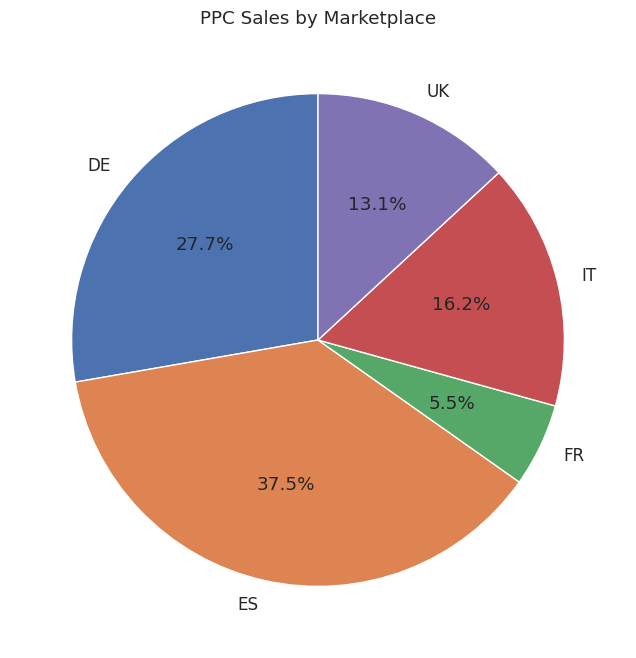

In [76]:
market_share = df.groupby("Market Place")["PPC Sales"].sum()

plt.figure(figsize=(8,8))

plt.pie(
    market_share,
    labels=market_share.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("PPC Sales by Marketplace")

plt.show()

---
# DASHBOARD 5: Refund Leakage & Quality Control

_Refund rates by SKU/marketplace, refund cost impact, quality control metrics._

---

## Call Library

In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot  as plt
import seaborn as sns
import plotly.express as px

## Load Data

> **Data Note:** This section uses `df` (the fully-joined Star Schema table), plus `fact_sales`, `dim_date`, `dim_product`, and `dim_market` (raw tables) and the aliases `df_merged` / `sales` — all loaded once in **Section 0** above. No separate loading needed.


## Explore the tables

In [78]:
fact_sales.head()

,Sales_Key,Date_ID,Market_ID,SKU_ID,Account Title,Taxes,Orders,Units,Refunded,Refund %,...,Impressions,Clicks,PPC Orders,PPC Sales,PPC Cost,PPC Conv,OOE,Net Profit,Net Margin,Net ROI
0,1,1,1,1,[ UK ] Aava,50.34,17,17,0,0.00,...,3423,13,2,29.36,13.06,0.15,0,56.28,0.19,0.31
1,2,2,1,1,[ UK ] Aava,58.89,20,20,0,0.00,...,2786,7,0,0.00,7.33,0.00,0,71.73,0.20,0.34
2,3,3,1,1,[ UK ] Aava,72.41,18,24,0,0.00,...,2927,7,1,14.69,6.15,0.14,0,61.37,0.14,0.24
3,4,4,1,1,[ UK ] Aava,41.43,13,14,0,0.00,...,3584,16,2,44.07,16.51,0.12,0,39.49,0.16,0.27
4,5,5,1,1,[ UK ] Aava,47.04,16,16,0,0.00,...,4329,7,0,0.00,4.47,0.00,0,59.86,0.21,0.36


In [80]:
dim_date.head()

,Date_ID,Date,Day,Month,Quarter,Year
0,1,2020-10-01,1,10,4,2020
1,2,2020-10-02,2,10,4,2020
2,3,2020-10-03,3,10,4,2020
3,4,2020-10-04,4,10,4,2020
4,5,2020-10-05,5,10,4,2020


In [79]:
dim_product.head()

,SKU_ID,SKU,FNSKU,ASIN,Parent ASIN,Is Parent,Brand,Title
0,1,UK_Aava_Magnesium_400mg_120_05,X000JJIQ79,B01GU9QLZC,No Parent,0,Aavalabs,High Absorption Magnesium Citrate Supplements ...
1,2,UK_Aava_Omega_2000mg_120_05,X000JFSY57,B01GU9P0M2,No Parent,0,Aavalabs,Omega 3 2000mg Fish Oil Capsules - High Streng...
2,3,UK_Aava_Turmeric_1400mg_120_07,X000J6KEPJ,B01GU8L68A,No Parent,0,Aavalabs,Turmeric Curcumin Capsules with Black Pepper [...
3,4,FR_Aava_Turmeric_1400mg_180_01,X000UL0561,B07CXYM3H5,No Parent,0,Aavalabs,Gélules biodisponibles du complexe de curcumin...
4,5,FR_Aava_Magnesium_400mg_120_01,X000UL0OUX,B07CZ1P4BM,No Parent,0,Aavalabs,"Citrate de Magnésium - 1496 mg dont 448,8 mg d..."


In [81]:
dim_market.head()

,Market_ID,Market Place,Account Title
0,1,UK,[ UK ] Aava
1,2,FR,[ FR ] Aava
2,3,DE,[ DE ] Aava
3,4,IT,[ IT ] Aava
4,5,ES,[ ES ] Aava


In [82]:
print(fact_sales.shape)
print(dim_date.shape)
print(dim_product.shape)
print(dim_market.shape)

(13323, 30)
(209, 6)
(102, 8)
(5, 3)


In [83]:
fact_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13323 entries, 0 to 13322
Data columns (total 30 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Sales_Key         13323 non-null  int64  
 1   Date_ID           13323 non-null  int64  
 2   Market_ID         13323 non-null  int64  
 3   SKU_ID            13323 non-null  int64  
 4   Account Title     13323 non-null  object 
 5   Taxes             13323 non-null  float64
 6   Orders            13323 non-null  int64  
 7   Units             13323 non-null  int64  
 8   Refunded          13323 non-null  int64  
 9   Refund %          13323 non-null  float64
 10  Unit Session %    13323 non-null  float64
 11  Promo Units       13323 non-null  int64  
 12  Organic Units     13323 non-null  int64  
 13  Per Unit Revenue  13323 non-null  float64
 14  Revenue           13323 non-null  float64
 15  COGS              13323 non-null  float64
 16  FBA Fees          13323 non-null  float6

In [84]:
fact_sales.isnull().sum()

,0
Sales_Key,0
Date_ID,0
Market_ID,0
SKU_ID,0
Account Title,0
Taxes,0
Orders,0
Units,0
Refunded,0
Refund %,0


In [85]:
fact_sales.describe()

,Sales_Key,Date_ID,Market_ID,SKU_ID,Taxes,Orders,Units,Refunded,Refund %,Unit Session %,...,Impressions,Clicks,PPC Orders,PPC Sales,PPC Cost,PPC Conv,OOE,Net Profit,Net Margin,Net ROI
count,"13,323.00","13,323.00","13,323.00","13,323.00","13,323.00","13,323.00","13,323.00","13,323.00","13,323.00","13,323.00",...,"13,323.00","13,323.00","13,323.00","13,323.00","13,323.00","13,323.00","13,323.00","13,323.00","13,323.00","13,323.00"
mean,"6,662.00",106.82,3.01,50.03,21.70,11.35,13.30,0.26,0.02,0.13,...,"4,165.73",15.58,2.33,51.90,15.25,0.14,0.00,61.22,0.17,0.29
std,"3,846.16",60.48,1.42,30.23,35.90,16.98,20.31,1.24,0.08,0.22,...,"6,593.38",25.22,4.11,94.22,26.14,0.26,0.00,110.08,0.16,0.31
min,1.00,1.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,-486.31,-4.95,-2.94
25%,"3,331.50",54.00,2.00,26.00,1.98,2.00,3.00,0.00,0.00,0.00,...,537.00,2.00,0.00,0.00,1.14,0.00,0.00,5.35,0.08,0.12
50%,"6,662.00",108.00,3.00,48.00,9.46,7.00,8.00,0.00,0.00,0.00,...,"1,917.00",7.00,1.00,18.17,6.33,0.08,0.00,24.96,0.19,0.29
75%,"9,992.50",160.00,4.00,80.00,25.19,14.00,16.00,0.00,0.00,0.25,...,"5,036.50",18.00,3.00,63.61,17.23,0.20,0.00,65.09,0.27,0.44
max,"13,323.00",209.00,5.00,102.00,"1,168.65",955.00,975.00,42.00,1.06,7.00,...,"121,882.00",713.00,135.00,"2,875.44","1,064.85",6.00,0.00,"2,342.19",0.73,2.70


In [86]:
dim_date.columns.tolist()

['Date_ID', 'Date', 'Day', 'Month', 'Quarter', 'Year']

## Data Merge

In [87]:
# NOTE: `sales` is already an alias for the fully-joined df from Section 0
# (Star_Schema sheet) — no re-merge needed here.
# (The original re-merge attempt used key names — 'Date_Key', 'Product_Key',
# 'Marketplace_Key' — that don't exist in this dataset; the real keys are
# 'Date_ID', 'SKU_ID', 'Market_ID', and the join was already performed
# upstream in the Gold Layer.)

sales.head()


,Sales_Key,Date_ID,Market_ID,SKU_ID,Account Title,Taxes,Orders,Units,Refunded,Refund %,...,ASIN,Parent ASIN,Is Parent,Brand,Title,Market Place,Account Title_mkt,Month_Name,Day_Name,Month_Year
0,1,1,1,1,[ UK ] Aava,50.34,17,17,0,0.00,...,B01GU9QLZC,No Parent,0,Aavalabs,High Absorption Magnesium Citrate Supplements ...,UK,[ UK ] Aava,October,Thursday,2020-October
1,2,2,1,1,[ UK ] Aava,58.89,20,20,0,0.00,...,B01GU9QLZC,No Parent,0,Aavalabs,High Absorption Magnesium Citrate Supplements ...,UK,[ UK ] Aava,October,Friday,2020-October
2,3,3,1,1,[ UK ] Aava,72.41,18,24,0,0.00,...,B01GU9QLZC,No Parent,0,Aavalabs,High Absorption Magnesium Citrate Supplements ...,UK,[ UK ] Aava,October,Saturday,2020-October
3,4,4,1,1,[ UK ] Aava,41.43,13,14,0,0.00,...,B01GU9QLZC,No Parent,0,Aavalabs,High Absorption Magnesium Citrate Supplements ...,UK,[ UK ] Aava,October,Sunday,2020-October
4,5,5,1,1,[ UK ] Aava,47.04,16,16,0,0.00,...,B01GU9QLZC,No Parent,0,Aavalabs,High Absorption Magnesium Citrate Supplements ...,UK,[ UK ] Aava,October,Monday,2020-October


In [88]:
sales.shape

(13323, 47)

In [89]:
sales.columns.tolist()

['Sales_Key',
 'Date_ID',
 'Market_ID',
 'SKU_ID',
 'Account Title',
 'Taxes',
 'Orders',
 'Units',
 'Refunded',
 'Refund %',
 'Unit Session %',
 'Promo Units',
 'Organic Units',
 'Per Unit Revenue',
 'Revenue',
 'COGS',
 'FBA Fees',
 'Promo Amount',
 'Sessions',
 'Page Views',
 'Impressions',
 'Clicks',
 'PPC Orders',
 'PPC Sales',
 'PPC Cost',
 'PPC Conv',
 'OOE',
 'Net Profit',
 'Net Margin',
 'Net ROI',
 'Date',
 'Day',
 'Month',
 'Quarter',
 'Year',
 'SKU',
 'FNSKU',
 'ASIN',
 'Parent ASIN',
 'Is Parent',
 'Brand',
 'Title',
 'Market Place',
 'Account Title_mkt',
 'Month_Name',
 'Day_Name',
 'Month_Year']

In [90]:
sales['Year'].value_counts()

,count
Year,
2021,7623
2020,5700


#Explore The Best KPIs

##1-Total Refunded Units

In [91]:
total_refunded = sales['Refunded'].sum()
total_refunded

np.int64(3446)

## 2-Refund Rate

In [92]:
refund_rate = (
    sales['Refunded'].sum() /
    sales['Units'].sum()
) * 100

print(f"Refund Rate: {refund_rate:.2f}%")

Refund Rate: 1.94%


## 3-High-Risk SKUs

In [93]:
sku_refund = sales.groupby('SKU').agg({
    'Refunded':'sum',
    'Units':'sum'
})

sku_refund['Refund_Rate'] = (
    sku_refund['Refunded'] /
    sku_refund['Units']
) * 100

avg_refund_rate = (
    sales['Refunded'].sum() /
    sales['Units'].sum()
) * 100

high_risk_skus = (
    sku_refund['Refund_Rate'] > avg_refund_rate
).sum()

print(high_risk_skus)

18


## 4-Revenue Lost Due to Refunds

In [94]:
sales['Revenue_Lost'] = (
    sales['Refunded'] *
    sales['Per Unit Revenue']
)

revenue_lost = sales['Revenue_Lost'].sum()

print(f"${revenue_lost:,.2f}")

$112,673.41


# Data Visulaization

## Prepar the data

In [95]:
sales['Refund_Cost_Impact'] = (
    sales['Refunded'] *
    sales['Per Unit Revenue']
)

monthly_refund = sales.groupby(
    ['Year', 'Month', 'Month_Name'],
    as_index=False
)['Refund_Cost_Impact'].sum()

monthly_refund = monthly_refund.sort_values(
    ['Year', 'Month']
)

monthly_refund['Month_Year'] = (
    monthly_refund['Month_Name']
    + '-'
    + monthly_refund['Year'].astype(str)
)

##Chart 1: Financial Impact of Refunds Over Time (Area Chart)

In [96]:
import pandas as pd
import plotly.express as px

sales['Refund_Cost_Impact'] = (
    sales['Refunded'].fillna(0) *
    sales['Per Unit Revenue'].fillna(0)
)

monthly_refund = sales.groupby(
    ['Year', 'Month'],
    as_index=False
)['Refund_Cost_Impact'].sum()

monthly_refund = monthly_refund.sort_values(['Year', 'Month'])

monthly_refund['Month_Year'] = pd.to_datetime(
    monthly_refund['Year'].astype(str) + '-' +
    monthly_refund['Month'].astype(str) + '-01'
)

fig = px.area(
    monthly_refund,
    x='Month_Year',
    y='Refund_Cost_Impact',
    markers=True,
    title='Financial Impact of Refunds Over Time',
    labels={
        'Month_Year': 'Month',
        'Refund_Cost_Impact': 'Revenue Lost Due to Refunds ($)'
    }
)

fig.update_layout(
    title_x=0.5,
    template='plotly_white',
    hovermode='x unified',
    height=600
)

fig.update_traces(
    hovertemplate='Date: %{x|%Y-%m}<br>Refund Loss: $%{y:,.2f}'
)

fig.show()

##Worst Offenders: Refund % by SKU Horizontal Bar Chart

In [97]:
import pandas as pd
import plotly.express as px

sku_refund = sales.groupby('SKU', as_index=False).agg({
    'Refunded': 'sum',
    'Units': 'sum'
})

sku_refund['Refund_Rate'] = (
    sku_refund['Refunded'] / sku_refund['Units']
).fillna(0) * 100

top_refund_skus = sku_refund.sort_values(
    'Refund_Rate',
    ascending=False
).head(10)

avg_refund_rate = (
    sales['Refunded'].sum() /
    sales['Units'].sum()
) * 100

fig = px.bar(
    top_refund_skus,
    x='Refund_Rate',
    y='SKU',
    orientation='h',
    title='Worst Offenders: Refund % by SKU',
    labels={
        'Refund_Rate': 'Refund Rate (%)',
        'SKU': 'SKU'
    }
)

fig.add_vline(
    x=avg_refund_rate,
    line_dash='dash',
    annotation_text=f'Average = {avg_refund_rate:.2f}%',
    annotation_position='top'
)

fig.update_layout(
    template='plotly_white',
    title_x=0.5,
    height=600,
    yaxis={'categoryorder': 'total ascending'}
)

fig.show()

## Chart 3: Refunds vs Net Margin Correlation (Scatter Plot)

In [98]:
sku_margin = sales.groupby('SKU').agg({
    'Refunded':'sum',
    'Units':'sum',
    'Net Profit':'sum',
    'Revenue':'sum'
}).reset_index()

sku_margin['Refund_Rate'] = (
    sku_margin['Refunded'] /
    sku_margin['Units']
) * 100

sku_margin['Net_Margin_Pct'] = (
    sku_margin['Net Profit'] /
    sku_margin['Revenue']
) * 100

In [99]:
sku_margin = sku_margin[
    sku_margin['Units'] >= 100
]

In [100]:
import plotly.express as px

fig = px.scatter(
    sku_margin,
    x='Refund_Rate',
    y='Net_Margin_Pct',
    hover_data=['SKU'],
    title='Refund Rate vs Net Margin'
)

fig.update_layout(
    template='plotly_white',
    title_x=0.5,
    xaxis_title='Refund Rate (%)',
    yaxis_title='Net Margin (%)',
    height=600
)

fig.show()

## 4-Refund Cost Impact by Marketplace

In [101]:
market_refund = sales.groupby('Market Place', as_index=False)[
    'Refund_Cost_Impact'
].sum()

market_refund = market_refund.sort_values(
    'Refund_Cost_Impact',
    ascending=False
)

In [102]:
fig = px.bar(
    market_refund,
    x='Market Place',
    y='Refund_Cost_Impact',
    title='Refund Cost Impact by Marketplace'
)

fig.update_layout(
    template='plotly_white',
    title_x=0.5
)

fig.show()

---
# DASHBOARD 6: Promotions & Returns Analysis

_Promo vs. organic units, promo spend trends, top products by promo units, promo vs. refund correlation._

---

# **Setup & Load Gold Layer Tables**

> **Data Note:** This section uses `df` (the fully-joined Star Schema table), plus `fact_sales`, `dim_date`, `dim_product`, and `dim_market` (raw tables) and the aliases `df_merged` / `sales` — all loaded once in **Section 0** above. No separate loading needed.


In [103]:
# NOTE: df is already the fully-joined Fact + all-Dimensions table loaded
# in Section 0 (Star_Schema sheet) — no re-merge needed here.
# (The original code referenced `dim_account_market`, which doesn't exist
# as a sheet in this workbook, and key names that don't match the real
# columns — the real Gold Layer join was already performed upstream.)

print('Using pre-merged df from Section 0:', df.shape)
df.head(3)


Using pre-merged df from Section 0: (13323, 49)


,Sales_Key,Date_ID,Market_ID,SKU_ID,Account Title,Taxes,Orders,Units,Refunded,Refund %,...,Is Parent,Brand,Title,Market Place,Account Title_mkt,Month_Name,Day_Name,Month_Year,Revenue_Lost,Refund_Cost_Impact
0,1,1,1,1,[ UK ] Aava,50.34,17,17,0,0.00,...,0,Aavalabs,High Absorption Magnesium Citrate Supplements ...,UK,[ UK ] Aava,October,Thursday,2020-October,0.00,0.00
1,2,2,1,1,[ UK ] Aava,58.89,20,20,0,0.00,...,0,Aavalabs,High Absorption Magnesium Citrate Supplements ...,UK,[ UK ] Aava,October,Friday,2020-October,0.00,0.00
2,3,3,1,1,[ UK ] Aava,72.41,18,24,0,0.00,...,0,Aavalabs,High Absorption Magnesium Citrate Supplements ...,UK,[ UK ] Aava,October,Saturday,2020-October,0.00,0.00


# **PAGE 6 — Promotions & Returns Analysis**
*(Power BI Page 6: "Promotions & Returns")*

**KPIs on this page:**
- Total Promo Units
- Total Promo Amount ($)
- Total Refunded Units
- Average Refund %

**Business Questions:**
1. What share of units sold come from Promotions vs Organic? → **Donut Chart**
2. How has Promo spend trended month over month? → **Line Chart**
3. What are the Top 10 products by Promo Units? → **Horizontal Bar Chart**
4. Is there a relationship between Promo Amount and Refund %? → **Scatter Plot**


In [104]:
# --- KPI Cards ---
total_promo_units = df['Promo Units'].sum()
total_promo_amount = df['Promo Amount'].sum()
total_refunded_units = df['Refunded'].sum()
avg_refund_pct = df['Refund %'].mean()

print(f"Total Promo Units:      {total_promo_units:,.0f}")
print(f"Total Promo Amount:     ${total_promo_amount:,.2f}")
print(f"Total Refunded Units:    {total_refunded_units:,.0f}")
print(f"Average Refund %:        {avg_refund_pct:.2%}")

Total Promo Units:      193
Total Promo Amount:     $156,765.64
Total Refunded Units:    3,446
Average Refund %:        1.71%


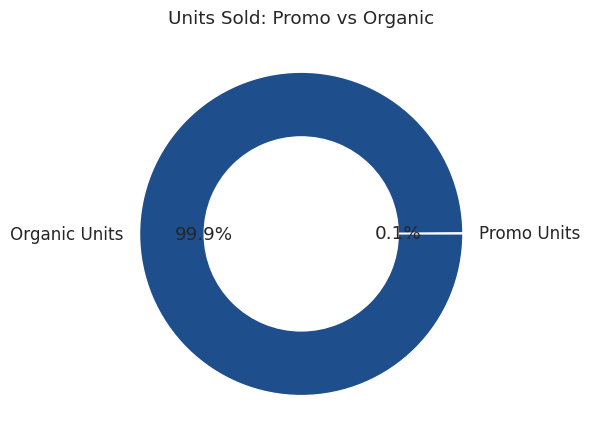

In [105]:
# Q1: Promo vs Organic Units Share -> Donut Chart
units_split = pd.DataFrame({
    'Type': ['Promo Units', 'Organic Units'],
    'Units': [df['Promo Units'].sum(), df['Organic Units'].sum()]
})

plt.figure(figsize=(6, 6))
plt.pie(units_split['Units'], labels=units_split['Type'], autopct='%1.1f%%',
        colors=['#e07b39', '#1f4e8c'], wedgeprops={'width': 0.4})
plt.title('Units Sold: Promo vs Organic')
plt.tight_layout()
plt.show()

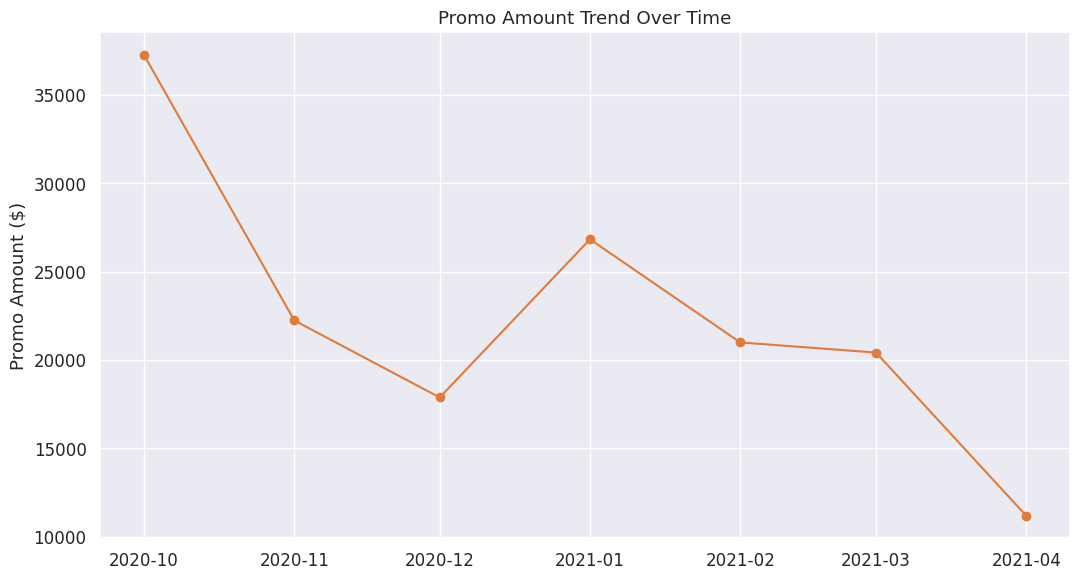

In [106]:
# Q2: Promo Spend Trend Over Time -> Line Chart
promo_trend = df.groupby(['Year', 'Month'], as_index=False).agg(Promo_Amount=('Promo Amount', 'sum'))
promo_trend['Period'] = pd.to_datetime(promo_trend[['Year', 'Month']].assign(DAY=1))
promo_trend = promo_trend.sort_values('Period')

plt.figure()
plt.plot(promo_trend['Period'], promo_trend['Promo_Amount'], marker='o', color='#e07b39')
plt.title('Promo Amount Trend Over Time')
plt.ylabel('Promo Amount ($)')
plt.tight_layout()
plt.show()

# Q3: Top 10 Products by Promo Units -> Horizontal Bar Chart


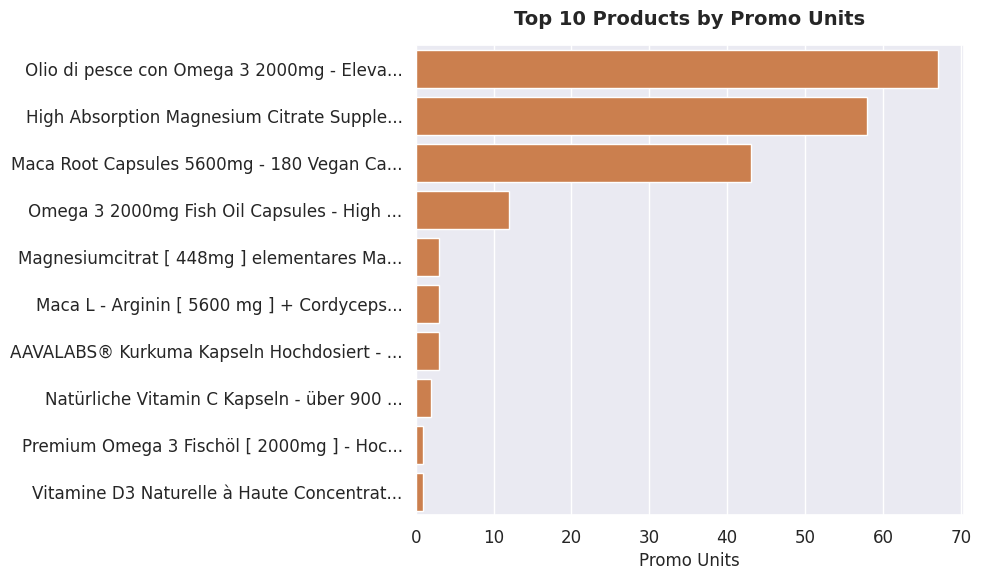

In [107]:
top10_promo = df.groupby('Title', as_index=False).agg(Promo_Units=('Promo Units', 'sum')).sort_values('Promo_Units', ascending=False).head(10)
top10_promo['Short_Title'] = top10_promo['Title'].apply(lambda x: x[:40] + '...' if len(str(x)) > 40 else x)
plt.figure(figsize=(10, 6))
sns.barplot(data=top10_promo, y='Short_Title', x='Promo_Units', color='#e07b39')
plt.title('Top 10 Products by Promo Units', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Promo Units', fontsize=12)
plt.ylabel('')

plt.tight_layout()
plt.show()

# Q4: Promo Amount vs Refund % -> Scatter Plot


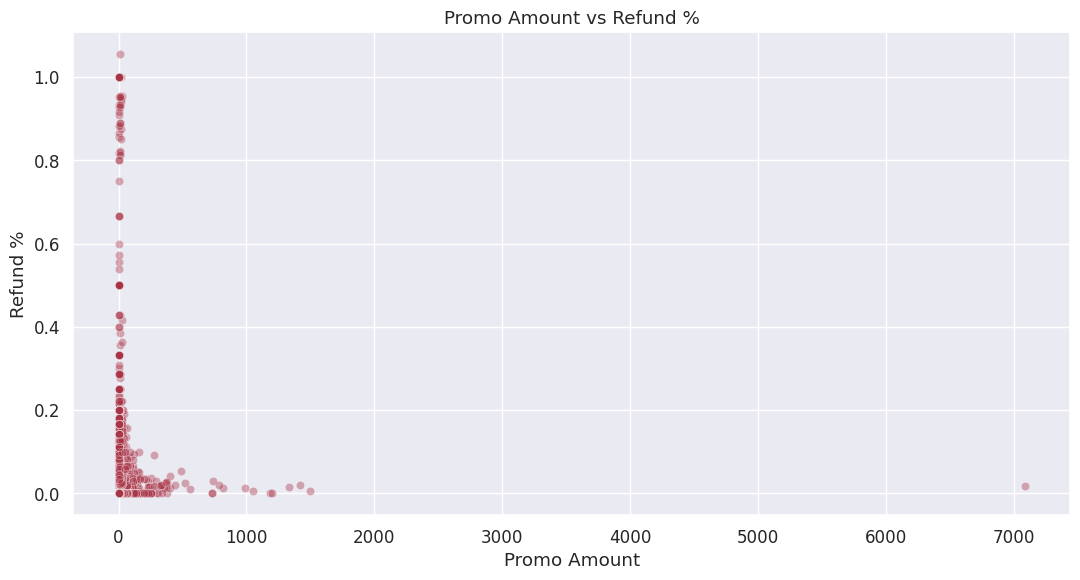

In [108]:
plt.figure()
sns.scatterplot(data=df, x='Promo Amount', y='Refund %', alpha=0.4, color='#a83246')
plt.title('Promo Amount vs Refund %')
plt.tight_layout()
plt.show()